<div style="color:white;
           display:fill;
           border-radius:5px;
           background-color:#5642C5;
           font-size:120%;
           font-family:Verdana;
           letter-spacing:0.5px">

<p style="padding: 10px;
              text-align:center;
              color:white;">
              <b>Ejecución con Docker</b>
</p>
</div>

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import sys
import geopandas as gpd
import numpy as np
import gstools as gs
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import os

In [2]:
from __future__ import division

import stan
import pickle
# import pybrms

# import os
# import sys
# import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import genextreme
from scipy.stats import gamma
from scipy.stats import cauchy

from statsmodels.distributions.empirical_distribution import ECDF

import arviz as az
#import Gevr as gevr
import nest_asyncio
import asyncio
nest_asyncio.apply()

import lmoments3 as lm
import lmoments3.distr as lmd

In [3]:
def plot_prior_posterior(fit, n_samples=1000, save=False):
   import numpy as np
   import matplotlib.pyplot as plt
   import seaborn as sns
   
   posterior_samples = fit.to_frame()
   params = ['mu', 'sigma', 'xi']
   
   prior_samples = {
       'mu': np.random.normal(0, 20, n_samples),
       'sigma': abs(cauchy.rvs(loc=0, scale=2.5, size=n_samples)),
       'xi': np.random.normal(0, 0.6, n_samples)
   }
   
   fig, axes = plt.subplots(1, 3, figsize=(15, 4))
   
   for i, param in enumerate(params):
       sns.kdeplot(data=posterior_samples[param], ax=axes[i], label='Posterior')
       sns.kdeplot(data=prior_samples[param], ax=axes[i], label='Prior')
       
       if param == 'xi':
           axes[i].set_xlim(-1, 1)
       elif param == 'sigma':
           axes[i].set_xlim(0, 40)
       else:  # mu
           axes[i].set_xlim(-50, 50)
           
       axes[i].set_title(param)
       axes[i].legend()
   
   plt.tight_layout()
   if save:
       plt.savefig('prior_posterior.png')
   plt.show()

In [4]:
def compare_return_periods(data, fit_bayes, fit_param, T_years=np.array([2,5,10,20,50,100]), plot=True):
    """
    Compara períodos de retorno entre análisis paramétrico y bayesiano
    
    Args:
        data: datos originales
        fit_bayes: ajuste bayesiano (objeto Stan)
        fit_param: parámetros del ajuste paramétrico (dict con 'mu', 'sigma', 'xi')
        T_years: array con periodos de retorno a calcular
        plot: si True, genera gráfico comparativo
    """
    import numpy as np
    from scipy.stats import genextreme as gev
    
    # Extraer parámetros medios del ajuste bayesiano
    bayes_params = fit_bayes.to_frame()
    bayes_mean = {
        'mu': np.mean(bayes_params['mu']),
        'sigma': np.mean(bayes_params['sigma']),
        'xi': np.mean(bayes_params['xi'])
    }

    t_years = np.arange(np.min(T_years), np.max(T_years),'100')
    
    # Calcular niveles de retorno
    p = 1 - 1/t_years
    
    # Bayesiano
    z_bayes = bayes_mean['mu'] - (bayes_mean['sigma']/bayes_mean['xi'])*(1 - (-np.log(p))**(-bayes_mean['xi']))
    # Paramétrico
    z_param = fit_param['mu'] - (fit_param['sigma']/fit_param['xi'])*(1 - (-np.log(p))**(-fit_param['xi']))
    
    if plot:
        plt.figure(figsize=(10,6))
        plt.plot(T_years, z_bayes, 'b-', label='Bayesiano')
        plt.plot(T_years, z_param, 'r--', label='Paramétrico')
        plt.scatter(T_years, z_bayes, c='b', s=5)
        plt.scatter(T_years, z_param, c='r', s = 5)
        plt.xlabel('Período de retorno (años)')
        plt.ylabel('Nivel de retorno')
        plt.xscale('log')
        plt.grid(True)
        plt.legend()
        plt.title('Comparación de niveles de retorno')
        plt.show()
        
    # Crear DataFrame con resultados
    import pandas as pd
    results = pd.DataFrame({
        'T': T_years,
        'Bayesiano': z_bayes,
        'Paramétrico': z_param,
        'Diferencia': z_bayes - z_param
    })
    
    return results

In [5]:
def compare_return_periods(data, fit_bayes, fit_param, T_years=np.array([2, 5, 10, 20, 50, 100]), 
                           plot=True, value=None, title="Comparación de niveles de retorno"):
    """
    Compara períodos de retorno entre análisis paramétrico, bayesiano y empírico.
    Permite calcular el período de retorno para un valor dado y visualizarlo.

    Args:
        data: datos originales.
        fit_bayes: ajuste bayesiano (objeto Stan o DataFrame simulado).
        fit_param: parámetros del ajuste paramétrico (dict con 'mu', 'sigma', 'xi').
        T_years: array con periodos de retorno a calcular.
        plot: si True, genera gráfico comparativo.
        value: valor para el cual calcular el período de retorno y marcarlo en el gráfico.
        title: título del gráfico (opcional).

    Returns:
        DataFrame con niveles de retorno calculados.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import genextreme as gev
    import pandas as pd

    # Extraer parámetros medios del ajuste bayesiano
    bayes_params = fit_bayes.to_frame()
    bayes_mean = {
        'mu': np.mean(bayes_params['mu']),
        'sigma': np.mean(bayes_params['sigma']),
        'xi': np.mean(bayes_params['xi'])
    }

    # Crear un rango denso de períodos de retorno para líneas suaves
    t_years = np.arange(np.min(T_years), np.max(T_years) + 1, 1)
    p_dense = 1 - 1 / t_years

    # Calcular niveles de retorno teóricos para el rango denso
    z_bayes_dense = gev.ppf(p_dense, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma'])
    z_param_dense = gev.ppf(p_dense, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma'])

    # Calcular niveles de retorno para los períodos especificados (T_years)
    p = 1 - 1 / T_years
    z_bayes = gev.ppf(p, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma'])
    z_param = gev.ppf(p, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma'])

    # Períodos de retorno empíricos
    sorted_data = np.sort(data)[::-1]  # Datos ordenados descendientemente
    n = len(sorted_data)
    emp_return_periods = (n + 1) / np.arange(1, n + 1)  # Períodos de retorno empíricos

    # Interpolación para obtener niveles empíricos en T_years
    z_emp = np.interp(T_years, emp_return_periods[::-1], sorted_data[::-1])

    # Calcular período de retorno para un valor dado
    if value is not None:
        # Bayesiano
        bayes_T = 1 / (1 - gev.cdf(value, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma']))

        # Paramétrico
        param_T = 1 / (1 - gev.cdf(value, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma']))

        # Empírico (aproximado)
        emp_T = np.interp(value, sorted_data[::-1], emp_return_periods[::-1])

    # Crear DataFrame con resultados y establecer T como índice
    results = pd.DataFrame({
        'Bayes': z_bayes,
        'Para': z_param,
        #'Empírico': z_emp,
        'Diff': z_bayes - z_param
    }, index=T_years).round(2)
    results.index.name = 'T'  # Nombrar el índice como T

    # Gráfico si se solicita
    if plot:
        plt.figure(figsize=(12, 18))

        # Niveles de retorno teóricos (líneas suaves)
        plt.plot(t_years, z_bayes_dense, 'b-', label='Bayesiano')
        plt.plot(t_years, z_param_dense, 'r--', label='Paramétrico')

        # Línea empírica ajustada
        # plt.plot(T_years, z_emp, color='g', linestyle='-', label='Empírico (Ajuste)')

        # Puntos calculados para T_years
        plt.scatter(T_years, z_bayes, c='b', label='Bayesiano (Puntos)', s=50, zorder=3)
        plt.scatter(T_years, z_param, c='r', label='Paramétrico (Puntos)', s=50, zorder=3)

        # Puntos empíricos calculados
        # plt.scatter(T_years, z_emp, c='g', label='Empírico (Puntos)', alpha=0.7, s=50, zorder=2)

        # Marcar el valor dado y añadir líneas
        if value is not None:
            plt.axhline(y=value, color='gray', linestyle='--', linewidth=1, label=f'Nivel: {value}')
            # Líneas verticales que terminan en el nivel
            plt.plot([bayes_T, bayes_T], [0, value], color='b', linestyle='--', linewidth=1)
            plt.plot([param_T, param_T], [0, value], color='r', linestyle='--', linewidth=1)
            # plt.plot([emp_T, emp_T], [0, value], color='g', linestyle='--', linewidth=1)

            # Etiquetas en el eje X
            plt.text(bayes_T, -2, f'{bayes_T:.2f}', color='b', fontsize=10, ha='center', va='top')
            plt.text(param_T, -2, f'{param_T:.2f}', color='r', fontsize=10, ha='center', va='top')
            # plt.text(emp_T, -2, f'{emp_T:.2f}', color='g', fontsize=10, ha='center', va='top')

        # Personalización del gráfico
        plt.xscale('log')
        plt.xlabel('Período de retorno (años)', fontsize=12)
        plt.ylabel('Nivel de retorno', fontsize=12)
        plt.title(title, fontsize=14)  # Usar el título proporcionado
        plt.legend()
        plt.grid(True)

        # Añadir tabla al gráfico con T como índice
        # table = plt.table(
        #     cellText=results.reset_index().values,
        #     colLabels=['T'] + list(results.columns),  # Añadir T como columna en la tabla
        #     cellLoc='center',
        #     loc='bottom',
        #     bbox=[0.0, -0.55, 1, 0.4]  # Más espacio inferior para evitar superposición
        # )
        # table.auto_set_font_size(False)
        # table.set_fontsize(10)  # Aumentar el tamaño de la fuente
        # table.scale(1, 2.5)  # Incrementar la altura de las filas

        plt.subplots_adjust(bottom=0.6)  # Espacio inferior ajustado para la tabla
        plt.show()

    return results


In [6]:
def filtrar_estaciones(df, min_years, max_gap_percentage):
    """
    Filtra estaciones que tienen al menos min_years años válidos con menos de max_gap_percentage de huecos.
    
    Args:
        df (pd.DataFrame): DataFrame con estaciones como columnas y fechas como índice.
        min_years (int): Número mínimo de años válidos requeridos.
        max_gap_percentage (float): Porcentaje máximo de huecos permitido por año.
    
    Returns:
        list: Lista de estaciones que cumplen con los criterios.
    """
    # Asegurarse de que el índice sea tipo datetime
    df.index = pd.to_datetime(df.index)
    
    # Resamplear para agrupar por año y contar datos válidos (no NaN)
    data_per_year = df.resample('Y').apply(lambda x: x.notna().sum())
    
    # Calcular el total de días por año
    total_days_per_year = df.resample('Y').size().values.reshape(-1, 1)
    
    # Calcular el porcentaje de huecos por estación por año
    percentage_gaps_per_year = 100 * (1 - (data_per_year / total_days_per_year))
    
    # Identificar años válidos (menos del max_gap_percentage de huecos)
    valid_years_per_station = (percentage_gaps_per_year < max_gap_percentage).astype(int)
    
    # Contar los años válidos por estación
    years_with_less_than_max_gap = valid_years_per_station.sum()
    
    # Filtrar estaciones con más de min_years años válidos
    stations_with_enough_valid_years = years_with_less_than_max_gap[years_with_less_than_max_gap >= min_years]
    
    # Devolver la lista de estaciones que cumplen los criterios
    return stations_with_enough_valid_years.index.tolist()

In [7]:
def ACOV(f, theta, x):
    '''
    Calcula la matriz de varianza-covarianza asintótica usando la inversa 
    de la matriz de información de Fisher.
    '''
    # Diferencial para parámetros
    pm = 0.00001
    params = np.asarray(theta)
    dt_p = pm * params
    
    # Matriz de información de Fisher
    ss = len(params)
    FI = np.ones((ss,ss)) * np.nan
    
    if np.isinf(f(theta, x)):
        print('ACOV error: nLogL = Inf. {0}'.format(theta))
        return np.ones((ss,ss))*0.0001
    
    # Cálculo de varianzas y covarianzas
    for i in range(ss):
        p1 = np.asarray(theta); p1[i] = p1[i] + dt_p[i]
        p2 = np.asarray(theta); p2[i] = p2[i] - dt_p[i]
        FI[i,i] = (f(tuple(p1), x) - 2*f(theta,x) + f(tuple(p2), x))/(dt_p[i]**2)
        
        for j in range(i+1,ss):
            p1 = np.asarray(theta); p1[i] = p1[i] - dt_p[i]
            p2 = np.asarray(theta); p2[j] = p2[j] - dt_p[j]
            p3 = np.asarray(theta); p3[i] = p3[i] - dt_p[i]; p3[j] = p3[j] - dt_p[j]
            
            cov = (f(theta,x) - f(tuple(p1),x) - f(tuple(p2),x) + f(tuple(p3),x)) \
                  / (dt_p[i]*dt_p[j])
            FI[i,j] = cov
            FI[j,i] = cov
    
    return np.linalg.inv(FI)

In [8]:
# Modelo GEV en Stan
gev_model = """
data {
   int<lower=0> N;
   vector[N] y;
}
parameters {
   real mu;
   real<lower=0> sigma;
   real xi;
}
model {
   // Priors
   mu ~ normal(0, 100);
   sigma ~ cauchy(0, 5);
   xi ~ normal(0, 5);
   
   // Likelihood
   for (n in 1:N) {
       if (xi != 0) {
           if (1 + xi * (y[n] - mu) / sigma > 0) {
               target += log(1/sigma) - (1 + 1/xi) * log1p(xi * (y[n] - mu) / sigma) 
                        - pow(1 + xi * (y[n] - mu) / sigma, -1/xi);
           } else {
               target += negative_infinity();
           }
       } else {
           target += log(1/sigma) - (y[n] - mu) / sigma 
                    - exp(-(y[n] - mu) / sigma);
       }
   }
}
"""

In [9]:
import pandas as pd
import numpy as np
import networkx as nx

def find_high_coincidence_group(df, threshold=0.8):
    """
    Encuentra el mayor grupo de estaciones con porcentaje de coincidencia temporal por encima de un umbral.

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con fechas en el índice y las estaciones en las columnas.
    
    threshold : float
        Porcentaje mínimo de coincidencia (ej. 0.8 significa 80%).

    Devuelve:
    ---------
    group : list
        Lista de nombres de las estaciones que forman el mayor grupo con alta coincidencia.
    """
    availability = df.notna().astype(int)
    stations = df.columns
    coincidence = pd.DataFrame(index=stations, columns=stations, dtype=float)

    # Calcula la matriz de coincidencia
    for s1 in stations:
        for s2 in stations:
            common_days = (availability[s1] & availability[s2]).sum()
            total_days = (availability[s1] | availability[s2]).sum()
            coincidence.loc[s1, s2] = common_days / total_days if total_days > 0 else np.nan

    # Construye el grafo de coincidencia
    G = nx.Graph()
    G.add_nodes_from(stations)
    for s1 in stations:
        for s2 in stations:
            if s1 != s2 and coincidence.loc[s1, s2] >= threshold:
                G.add_edge(s1, s2)

    # Busca el clique máximo (grupo máximo de estaciones completamente conectadas)
    cliques = list(nx.find_cliques(G))
    largest_clique = max(cliques, key=len)

    return largest_clique

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_stations_with_wms(stations_df, lon_col='lon', lat_col='lat'):
    """
    Plotea estaciones con línea de costa y límites de CCAA desde WMS del IGN.

    Parámetros:
    -----------
    stations_df : pandas.DataFrame
        DataFrame con columnas de coordenadas (lon, lat).
    """
    proj = ccrs.PlateCarree()

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': proj})

    # Mapa base
    ax.coastlines(resolution='10m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.LAKES, edgecolor='black', facecolor='lightblue')
    ax.add_feature(cfeature.RIVERS)

    # --- Ploteo de las estaciones ---
    ax.scatter(stations_df[lon_col], stations_df[lat_col],
               color='red', edgecolor='black', s=50, transform=proj, label='Estaciones')

    # Ajusta la extensión
    buffer = 1.0  # grados
    minx, miny = stations_df[lon_col].min() - buffer, stations_df[lat_col].min() - buffer
    maxx, maxy = stations_df[lon_col].max() + buffer, stations_df[lat_col].max() + buffer
    ax.set_extent([minx, maxx, miny, maxy], crs=proj)

    # Leyenda y título
    ax.legend(loc='lower left')
    ax.set_title('Estaciones con línea de costa y CCAA (WMS IGN)', fontsize=14)
    plt.tight_layout()
    plt.show()

In [11]:
import geopandas as gpd
from shapely.geometry import Point

def stations_to_gdf(df, lon_col='lon', lat_col='lat'):
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    return gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

def select_stations_by_real_distance(stations_df, coast_line_shapefile, lon_col='lon', lat_col='lat', distance_km=40):
    stations_gdf = stations_to_gdf(stations_df, lon_col, lat_col).to_crs(epsg=25830)
    coastline = gpd.read_file(coast_line_shapefile).to_crs(epsg=25830)
    coastline = coastline[coastline.is_valid & ~coastline.is_empty]

    # Aquí no da error porque es LINESTRING
    coastline_union = coastline.union_all()  # O usa coastline.union_all() si prefieres evitar el warning

    stations_gdf['distance_to_coast_m'] = stations_gdf.geometry.apply(lambda point: point.distance(coastline_union))
    selected = stations_gdf[stations_gdf['distance_to_coast_m'] <= distance_km * 1000]
    
    return selected

# Análisis precipitaciones máximas

In [12]:
df = pd.read_csv('./data/Estaciones_Conjuntas.csv',index_col=0)
prec_day = pd.read_csv('./data/Daily_series_conjuntas.csv',index_col=0, parse_dates=True).astype(float)


In [13]:
sel_estation = find_high_coincidence_group(prec_day, threshold=0.2)
df = df.loc[sel_estation]
sel_estation = select_stations_by_real_distance(df,coast_line_shapefile='./data/ne_10m_coastline.shp', lon_col='Longitud', lat_col='Latitud', distance_km=50).index
df = df.loc[sel_estation]
prec_day = prec_day.loc[:,sel_estation]
prec_year_max = prec_day.resample('YE').max()

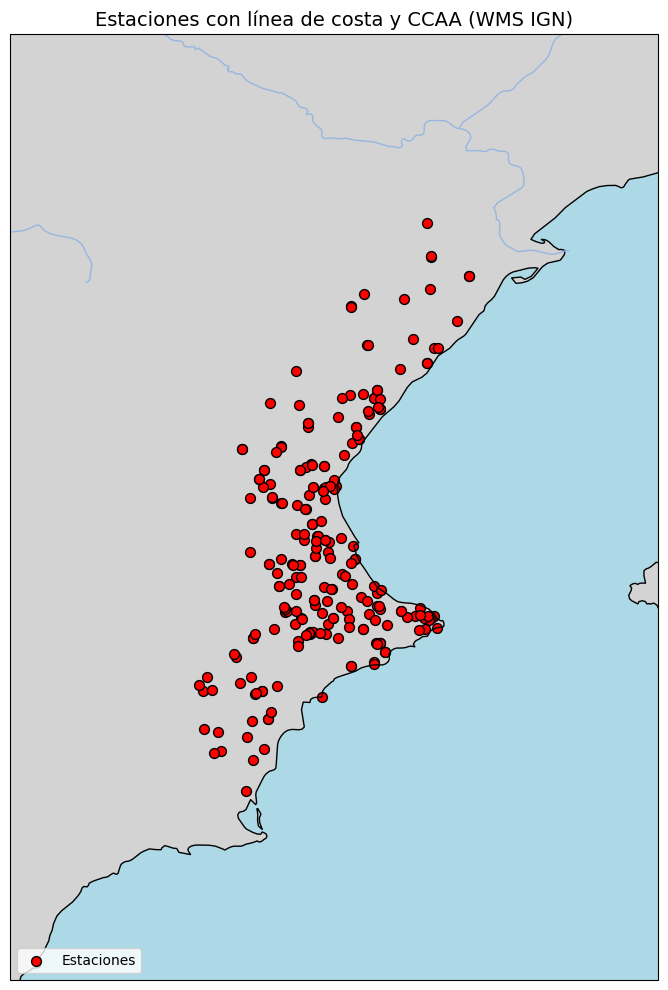

In [14]:
plot_stations_with_wms(df, lon_col='Longitud', lat_col='Latitud')

# Análisis Bayesiano

In [15]:
def plot_prior_posterior(fit, n_samples=1000, save=False):
   import numpy as np
   import matplotlib.pyplot as plt
   import seaborn as sns
   
   posterior_samples = fit.to_frame()
   params = ['mu', 'sigma', 'xi']
   
   prior_samples = {
       'mu': np.random.normal(0, 20, n_samples),
       'sigma': abs(cauchy.rvs(loc=0, scale=2.5, size=n_samples)),
       'xi': np.random.normal(0, 0.6, n_samples)
   }
   
   fig, axes = plt.subplots(1, 3, figsize=(15, 4))
   
   for i, param in enumerate(params):
       sns.kdeplot(data=posterior_samples[param], ax=axes[i], label='Posterior')
       sns.kdeplot(data=prior_samples[param], ax=axes[i], label='Prior')
       
       if param == 'xi':
           axes[i].set_xlim(-1, 1)
       elif param == 'sigma':
           axes[i].set_xlim(0, 40)
       else:  # mu
           axes[i].set_xlim(-50, 50)
           
       axes[i].set_title(param)
       axes[i].legend()
   
   plt.tight_layout()
   if save:
       plt.savefig('prior_posterior.png')
   plt.show()

In [16]:
def compare_return_periods(data, fit_bayes, fit_param, T_years=np.array([2,5,10,20,50,100]), plot=True):
    """
    Compara períodos de retorno entre análisis paramétrico y bayesiano
    
    Args:
        data: datos originales
        fit_bayes: ajuste bayesiano (objeto Stan)
        fit_param: parámetros del ajuste paramétrico (dict con 'mu', 'sigma', 'xi')
        T_years: array con periodos de retorno a calcular
        plot: si True, genera gráfico comparativo
    """
    import numpy as np
    from scipy.stats import genextreme as gev
    
    # Extraer parámetros medios del ajuste bayesiano
    bayes_params = fit_bayes.to_frame()
    bayes_mean = {
        'mu': np.mean(bayes_params['mu']),
        'sigma': np.mean(bayes_params['sigma']),
        'xi': np.mean(bayes_params['xi'])
    }

    t_years = np.arange(np.min(T_years), np.max(T_years),'100')
    
    # Calcular niveles de retorno
    p = 1 - 1/t_years
    
    # Bayesiano
    z_bayes = bayes_mean['mu'] - (bayes_mean['sigma']/bayes_mean['xi'])*(1 - (-np.log(p))**(-bayes_mean['xi']))
    # Paramétrico
    z_param = fit_param['mu'] - (fit_param['sigma']/fit_param['xi'])*(1 - (-np.log(p))**(-fit_param['xi']))
    
    if plot:
        plt.figure(figsize=(10,6))
        plt.plot(T_years, z_bayes, 'b-', label='Bayesiano')
        plt.plot(T_years, z_param, 'r--', label='Paramétrico')
        plt.scatter(T_years, z_bayes, c='b', s=5)
        plt.scatter(T_years, z_param, c='r', s = 5)
        plt.xlabel('Período de retorno (años)')
        plt.ylabel('Nivel de retorno')
        plt.xscale('log')
        plt.grid(True)
        plt.legend()
        plt.title('Comparación de niveles de retorno')
        plt.show()
        
    # Crear DataFrame con resultados
    import pandas as pd
    results = pd.DataFrame({
        'T': T_years,
        'Bayesiano': z_bayes,
        'Paramétrico': z_param,
        'Diferencia': z_bayes - z_param
    })
    
    return results

In [71]:
def compare_return_periods(data, fit_bayes, fit_param,fit_lmoments, dx1=0, dx2=0, dx3=0, dy1=0, dy2=0, dy3=0, T_years=np.array([2, 5, 10, 20, 50, 100]), 
                           plot=True, value=None, title="Comparison of Return Levels", savefile=None):
    """
    Compara períodos de retorno entre análisis paramétrico, bayesiano y empírico.
    Permite calcular el período de retorno para un valor dado y visualizarlo.

    Args:
        data: datos originales.
        fit_bayes: ajuste bayesiano (objeto Stan o DataFrame simulado).
        fit_param: parámetros del ajuste paramétrico (dict con 'mu', 'sigma', 'xi').
        T_years: array con periodos de retorno a calcular.
        plot: si True, genera gráfico comparativo.
        value: valor para el cual calcular el período de retorno y marcarlo en el gráfico.
        title: título del gráfico (opcional).

    Returns:
        DataFrame con niveles de retorno calculados.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import genextreme as gev
    import pandas as pd

    # Extraer parámetros medios del ajuste bayesiano
    bayes_params = fit_bayes.to_frame()
    bayes_mean = {
        'mu': np.mean(bayes_params['mu']),
        'sigma': np.mean(bayes_params['sigma']),
        'xi': np.mean(bayes_params['xi'])
    }

    # Crear un rango denso de períodos de retorno para líneas suaves
    t_years = np.arange(np.min(T_years), np.max(T_years) + 1, 1)
    p_dense = 1 - 1 / t_years

    # Calcular niveles de retorno teóricos para el rango denso
    z_bayes_dense    = gev.ppf(p_dense, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma'])
    z_param_dense    = gev.ppf(p_dense, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma'])
    z_lmoments_dense = gev.ppf(p_dense, c=-fit_lmoments['xi'], loc=fit_lmoments['mu'], scale=fit_lmoments['sigma'])

    # Calcular niveles de retorno para los períodos especificados (T_years)
    p = 1 - 1 / T_years
    z_bayes    = gev.ppf(p, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma'])
    z_param    = gev.ppf(p, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma'])
    z_lmoments = gev.ppf(p, c=-fit_lmoments['xi'], loc=fit_lmoments['mu'], scale=fit_lmoments['sigma'])

    # Calcular período de retorno para un valor dado
    if value is not None:
        # Bayesiano
        bayes_T = 1 / (1 - gev.cdf(value, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma']))

        # Paramétrico
        param_T = 1 / (1 - gev.cdf(value, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma']))

        # L-Moments
        lmoments_T = 1 / (1 - gev.cdf(value, c=-fit_lmoments['xi'], loc=fit_lmoments['mu'], scale=fit_lmoments['sigma']))

    # Crear DataFrame con resultados y establecer T como índice
    results = pd.DataFrame({
        'Bayes': z_bayes,
        'Para': z_param,
        'l-moments': z_lmoments,
    }, index=T_years).round(2)
    results.index.name = 'T'  # Nombrar el índice como T

    # Gráfico si se solicita
    if plot:
        plt.figure(figsize=(12, 18))

        # Niveles de retorno teóricos (líneas suaves)
        plt.plot(t_years, z_bayes_dense, 'b-', label='Bayesian')
        plt.plot(t_years, z_param_dense, 'r--', label='Parametric')
        plt.plot(t_years, z_lmoments_dense, 'g--', label='L-Moments')

        # Línea empírica ajustada
        # plt.plot(T_years, z_emp, color='g', linestyle='-', label='Empírico (Ajuste)')

        # Puntos calculados para T_years
        plt.scatter(T_years, z_bayes, c='b', label='Bayesian (Points)', s=50, zorder=3)
        plt.scatter(T_years, z_param, c='r', label='Parametric (Points)', s=50, zorder=3)
        plt.scatter(T_years, z_lmoments, c='g', label='L-Moments (Points)', s=50, zorder=3)

        # Puntos empíricos calculados
        # plt.scatter(T_years, z_emp, c='g', label='Empírico (Puntos)', alpha=0.7, s=50, zorder=2)

        # Marcar el valor dado y añadir líneas
        if value is not None:
            plt.axhline(y=value, color='gray', linestyle='--', linewidth=1, label=f'Level: {value}')
            # Líneas verticales que terminan en el nivel
            plt.plot([bayes_T, bayes_T], [0, value], color='b', linestyle='--', linewidth=1)
            plt.plot([param_T, param_T], [0, value], color='r', linestyle='--', linewidth=1)
            plt.plot([lmoments_T, lmoments_T], [0, value], color='g', linestyle='--', linewidth=1)

            # Etiquetas en el eje X
            plt.text(bayes_T+dx1, -2+dy1, f'{bayes_T:.2f}', color='b', fontsize=10, ha='center', va='top')
            plt.text(param_T+dx2, -2+dy2, f'{param_T:.2f}', color='r', fontsize=10, ha='center', va='top')
            plt.text(lmoments_T+dx3, -2+dy3, f'{lmoments_T:.2f}', color='g', fontsize=10, ha='center', va='top')

        # Personalización del gráfico
        plt.xscale('log')
        plt.xlabel('Return period (years)', fontsize=12)
        plt.ylabel('Return level', fontsize=12)
        plt.title(title, fontsize=14)  # Usar el título proporcionado
        plt.legend()
        plt.grid(True)

        # Añadir tabla al gráfico con T como índice
        # table = plt.table(
        #     cellText=results.reset_index().values,
        #     colLabels=['T'] + list(results.columns),  # Añadir T como columna en la tabla
        #     cellLoc='center',
        #     loc='bottom',
        #     bbox=[0.0, -0.55, 1, 0.4]  # Más espacio inferior para evitar superposición
        # )
        # table.auto_set_font_size(False)
        # table.set_fontsize(10)  # Aumentar el tamaño de la fuente
        # table.scale(1, 2.5)  # Incrementar la altura de las filas

        plt.subplots_adjust(bottom=0.6)  # Espacio inferior ajustado para la tabla
        if savefile is not None:
            from os.path import join as opj
            plt.savefig(opj("output", savefile), dpi=600, bbox_inches='tight')
        plt.show()



    return results


In [18]:
# Modelo GEV en Stan
gev_model = """
data {
   int<lower=0> N;
   vector[N] y;
}
parameters {
   real mu;
   real<lower=0> sigma;
   real xi;
}
model {
   // Priors
   mu ~ normal(0, 100);
   sigma ~ cauchy(0, 5);
   xi ~ normal(0, 5);
   
   // Likelihood
   for (n in 1:N) {
       if (xi != 0) {
           if (1 + xi * (y[n] - mu) / sigma > 0) {
               target += log(1/sigma) - (1 + 1/xi) * log1p(xi * (y[n] - mu) / sigma) 
                        - pow(1 + xi * (y[n] - mu) / sigma, -1/xi);
           } else {
               target += negative_infinity();
           }
       } else {
           target += log(1/sigma) - (y[n] - mu) / sigma 
                    - exp(-(y[n] - mu) / sigma);
       }
   }
}
"""

# Análisis Puntual

## No considerando el valor máximo diario asociado a la DANA de octubre de 2024. Estudio estación 8337X

In [72]:
station = '8337X' 

In [73]:
data = prec_day.loc[:'2023',station].resample('D').sum(min_count=1).resample('YE').max(min_count=1).dropna()

In [74]:
p       = 1 / 500
z_value = prec_day[station].resample('D').sum(min_count=1).resample('YE').max(min_count=1).dropna().max()

In [75]:
z_value

np.float64(710.8)

In [76]:
shape_gev, loc_gev, scale_gev = genextreme.fit(data)
print(shape_gev, loc_gev, scale_gev)

-0.21540152379929078 56.114497203241015 21.739901158961842


In [77]:
max_return_period_gev = 1 / (1 - genextreme.cdf(z_value, shape_gev, loc=loc_gev, scale=scale_gev))
print(max_return_period_gev)

11452.660008173774


In [78]:
return_levels_gumbel = [genextreme.ppf(1 - 1 / rp, shape_gev, loc=loc_gev, scale=scale_gev) for rp in [500]]

In [79]:
# Preparar datos para Stan
data_dict = {
    'N': len(data),
    'y': data.values.astype(float)  # o data.to_numpy() si es un DataFrame
}
posterior = stan.build(gev_model, data=data_dict,random_seed=42)
# Ajustar modelo
fit = posterior.sample(num_chains=20, num_samples=10000, num_warmup=2000)
# Mostrar los resultados

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 4e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.4 seconds.
  Adjust your expectations accordingly!
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
warn:Rejecting initial value:
warn:  Log probability ev

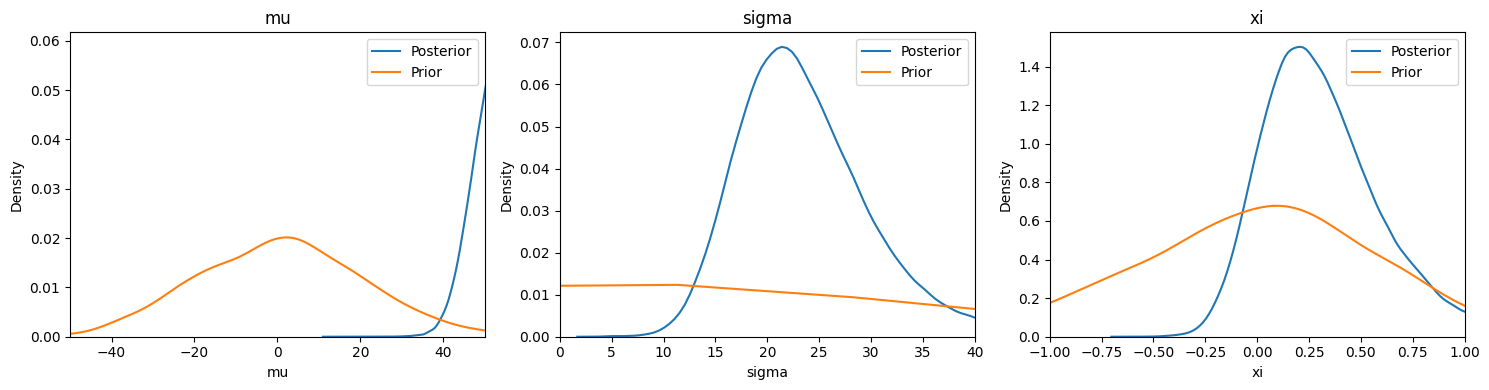

In [80]:
plot_prior_posterior(fit)

In [81]:
print(f"ξ: {fit.to_frame()['xi'].mean()}")
print(f"μ: {fit.to_frame()['mu'].mean()}")
print(f"σ: {fit.to_frame()['sigma'].mean()}")

ξ: 0.3245586625205525
μ: 54.78986018303086
σ: 23.732656785326405


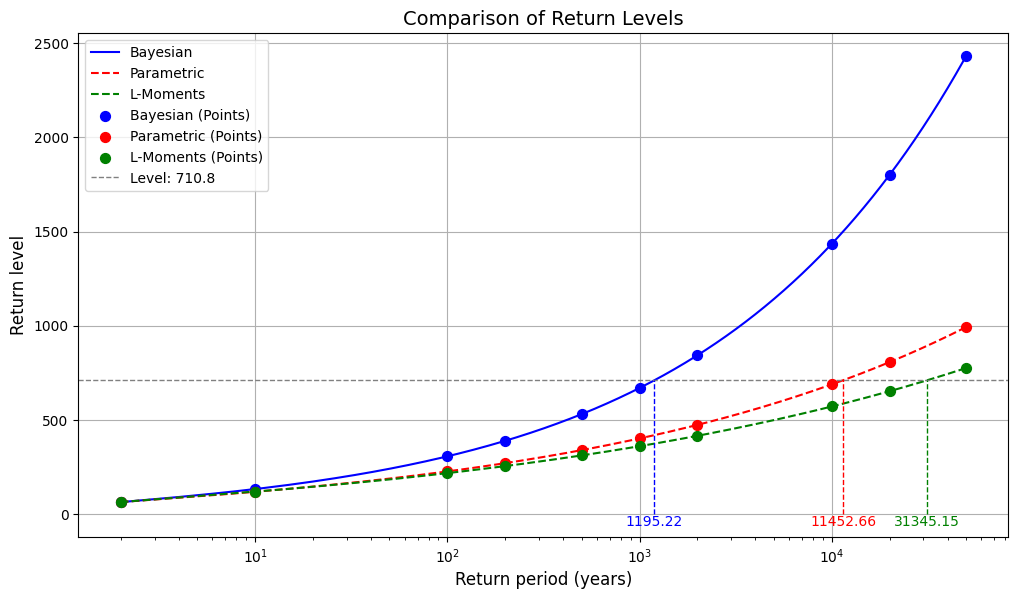

         Bayes    Para  l-moments
T                                
2        64.03   64.41      64.54
10      133.46  119.07     119.58
100     307.10  227.05     217.95
200     389.53  270.99     255.39
500     531.06  340.02     312.00
1000    669.78  402.04     361.00
2000    843.45  474.03     416.06
10000  1434.72  689.04     571.68
20000  1801.31  807.22     652.87
50000  2431.54  993.13     775.85


In [82]:
lmoments = lm.lmom_ratios(data)
ξ_est, μ_est, σ_est = genextreme.fit(data)
gev_params_lmoments = lmd.gev.lmom_fit(data)
ξ_est_lm = gev_params_lmoments['c']
μ_est_lm = gev_params_lmoments['loc'] 
σ_est_lm = gev_params_lmoments['scale']

# Uso:
T_years = np.array([2,10,100,200,500, 1000, 2000, 10000, 20000, 50000])
param_fit = {'mu': μ_est, 'sigma': σ_est, 'xi': -ξ_est}
param_fit_lm = {'mu': μ_est_lm, 'sigma': σ_est_lm, 'xi': -ξ_est_lm}
results = compare_return_periods(data, fit, param_fit,param_fit_lm, dx1=0, dx2=0, dx3=0, dy1=0, dy2=0, dy3=0,
                                 T_years = T_years,value=z_value, savefile="Analisis_Basic_Excluding.jpg")
print(results)

In [83]:
os.makedirs('Resultados_RP/Puntual/',exist_ok=True)
results.to_csv('Resultados_RP/Puntual/Analisis_Puntual_RP_8337X_SIN_DANA.csv')

## Considerando el valor máximo diario asociado a la DANA de octubre de 2024 en la estación de 8337X

In [84]:
data = prec_day.loc[:'2024',station].resample('D').sum(min_count=1).resample('YE').max(min_count=1).dropna()

In [85]:
shape_gev, loc_gev, scale_gev = genextreme.fit(data)
print(shape_gev, loc_gev, scale_gev)

-0.6662768003952131 55.13687900738429 24.998044671063028


In [86]:
max_return_period_gev = 1 / (1 - genextreme.cdf(z_value, shape_gev, loc=loc_gev, scale=scale_gev))
print(max_return_period_gev)

80.11803051962433


In [87]:
return_levels_gumbel = [genextreme.ppf(1 - 1 / rp, shape_gev, loc=loc_gev, scale=scale_gev) for rp in [10]]

In [88]:
p       = 1 / 500
z_value = prec_day[station].resample('D').sum(min_count=1).resample('YE').max(min_count=1).dropna().max()

In [89]:
# Preparar datos para Stan
data_dict = {
    'N': len(data),
    'y': data.values.astype(float)  # o data.to_numpy() si es un DataFrame
}
posterior = stan.build(gev_model, data=data_dict,random_seed=42)
# Ajustar modelo
fit = posterior.sample(num_chains=20, num_samples=10000, num_warmup=2000)
# Mostrar los resultados

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 1.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.16 seconds.
  Adjust your expectations accordingly!
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
warn:Rejecting initial value:
warn:  Log probability

In [90]:
print(f"ξ: {fit.to_frame()['xi'].mean()}")
print(f"μ: {fit.to_frame()['mu'].mean()}")
print(f"σ: {fit.to_frame()['sigma'].mean()}")

ξ: 0.7666193182747613
μ: 53.78834176297112
σ: 26.746457630591124


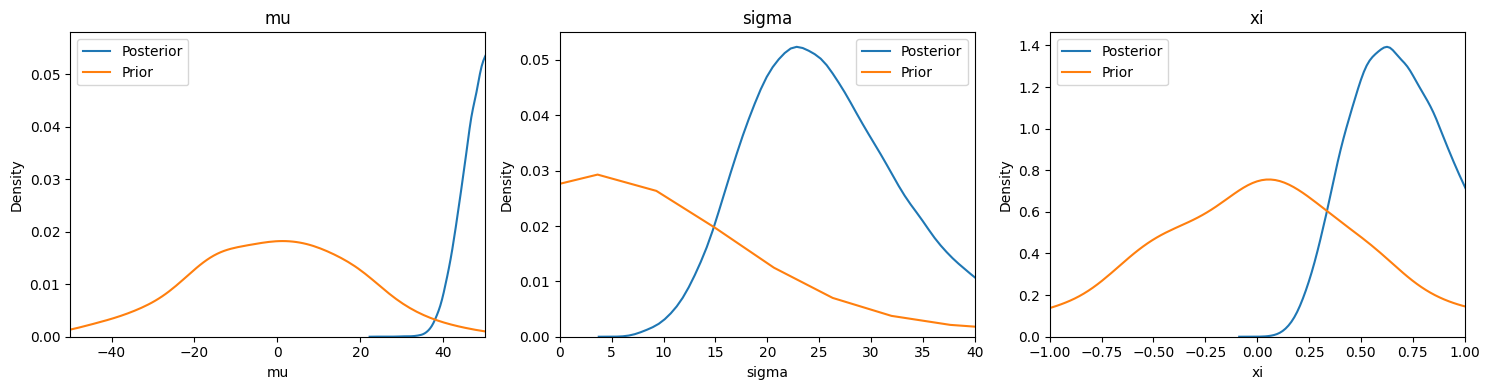

In [91]:
plot_prior_posterior(fit)

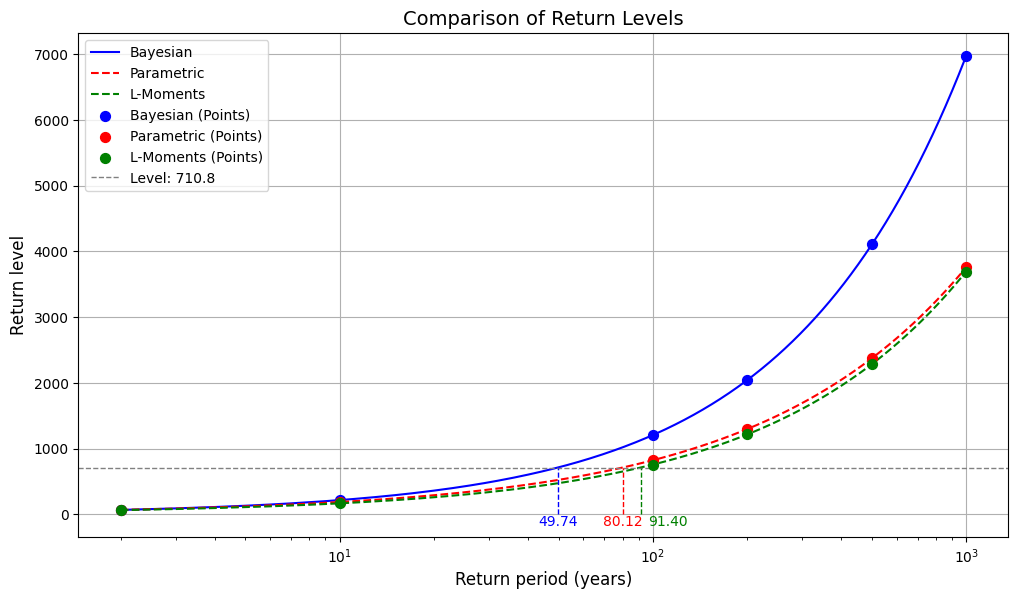

        Bayes     Para  l-moments
T                                
2       65.11    65.51      61.67
10     214.75   185.66     165.35
100   1205.36   821.80     755.63
200   2041.30  1295.97    1213.95
500   4106.19  2373.88    2284.36
1000  6975.19  3758.18    3694.76


In [92]:
lmoments = lm.lmom_ratios(data)
ξ_est, μ_est, σ_est = genextreme.fit(data)
gev_params_lmoments = lmd.gev.lmom_fit(data)
ξ_est_lm = gev_params_lmoments['c']
μ_est_lm = gev_params_lmoments['loc'] 
σ_est_lm = gev_params_lmoments['scale']

# Uso:
T_years = np.array([2,10,100,200,500, 1000])
param_fit = {'mu': μ_est, 'sigma': σ_est, 'xi': -ξ_est}
param_fit_lm = {'mu': μ_est_lm, 'sigma': σ_est_lm, 'xi': -ξ_est_lm}
results = compare_return_periods(data, fit, param_fit,param_fit_lm, dx1=0, dx2=0, dx3=20, dy1=0, dy2=0, dy3=0,
                                 T_years=T_years,value=z_value, savefile="Analisis_Basic_Including.jpg")
print(results)

In [93]:
os.makedirs('Resultados_RP/Puntual/',exist_ok=True)
results.to_csv('Resultados_RP/Puntual/Analisis_Puntual_RP_8337X_CON_DANA.csv')

## No considerando el valor máximo diario asociado a la DANA de octubre de 2024. Estudio estación V103

In [94]:
station = 'V103' 

In [95]:
data = prec_day.loc[:'2023',station].resample('D').sum(min_count=1).resample('YE').max(min_count=1).dropna()

In [96]:
p       = 1 / 500
z_value = prec_day[station].resample('D').sum(min_count=1).resample('YE').max(min_count=1).dropna().max()

In [97]:
z_value

np.float64(265.1)

In [98]:
shape_gev, loc_gev, scale_gev = genextreme.fit(data)
print(shape_gev, loc_gev, scale_gev)

-0.01873840719598633 61.891234981600434 25.648096744813905


In [99]:
max_return_period_gev = 1 / (1 - genextreme.cdf(z_value, shape_gev, loc=loc_gev, scale=scale_gev))
print(max_return_period_gev)

1615.7360316000913


In [100]:
return_levels_gumbel = [genextreme.ppf(1 - 1 / rp, shape_gev, loc=loc_gev, scale=scale_gev) for rp in [500]]

In [101]:
# Preparar datos para Stan
data_dict = {
    'N': len(data),
    'y': data.values.astype(float)  # o data.to_numpy() si es un DataFrame
}
posterior = stan.build(gev_model, data=data_dict,random_seed=42)
# Ajustar modelo
fit = posterior.sample(num_chains=20, num_samples=10000, num_warmup=2000)
# Mostrar los resultados

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 2.9e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.29 seconds.
  Adjust your expectations accordingly!
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
warn:Rejecting initial value:
warn:  Log probability

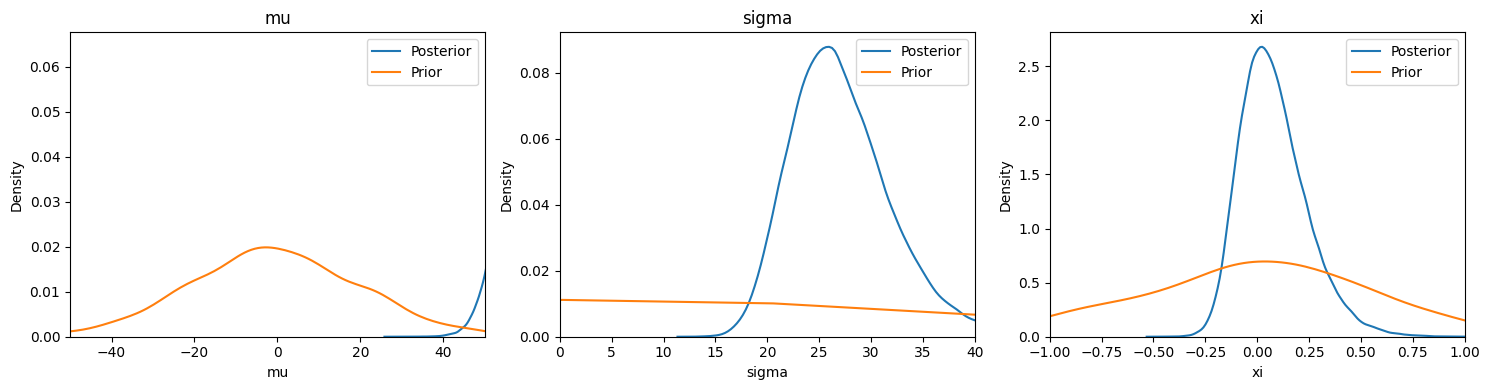

In [102]:
plot_prior_posterior(fit)

In [103]:
print(f"ξ: {fit.to_frame()['xi'].mean()}")
print(f"μ: {fit.to_frame()['mu'].mean()}")
print(f"σ: {fit.to_frame()['sigma'].mean()}")

ξ: 0.08067187731988283
μ: 60.79803611431069
σ: 27.197836813494387


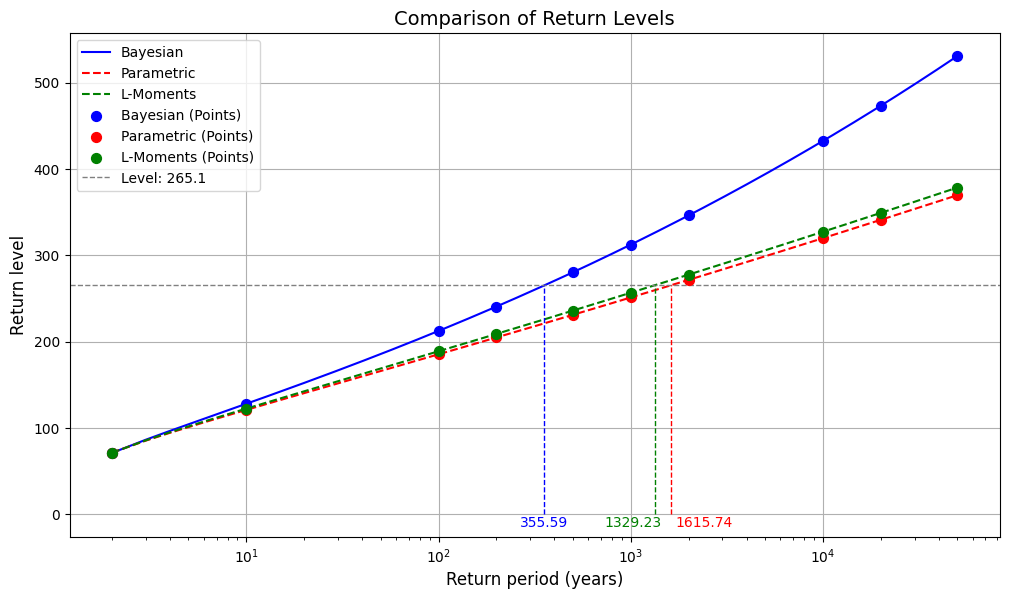

        Bayes    Para  l-moments
T                               
2       70.92   71.32      71.13
10     127.91  120.84     122.31
100    212.29  185.11     188.62
200    240.49  204.69     208.80
500    280.21  230.91     235.81
1000   312.24  251.03     256.52
2000   346.11  271.40     277.49
10000  432.41  319.73     327.17
20000  473.18  340.99     349.02
50000  530.68  369.53     378.32


In [104]:
lmoments = lm.lmom_ratios(data)
ξ_est, μ_est, σ_est = genextreme.fit(data)
gev_params_lmoments = lmd.gev.lmom_fit(data)
ξ_est_lm = gev_params_lmoments['c']
μ_est_lm = gev_params_lmoments['loc'] 
σ_est_lm = gev_params_lmoments['scale']

# Uso:
T_years = np.array([2,10,100,200,500, 1000, 2000, 10000, 20000, 50000])
param_fit = {'mu': μ_est, 'sigma': σ_est, 'xi': -ξ_est}
param_fit_lm = {'mu': μ_est_lm, 'sigma': σ_est_lm, 'xi': -ξ_est_lm}
results = compare_return_periods(data, fit, param_fit,param_fit_lm, dx1=0, dx2=800, dx3=-300, dy1=0, dy2=0, dy3=0,
                                 T_years=T_years,value=z_value, savefile="Analisis_Basic_Excluding_2.jpg")
print(results)

In [105]:
os.makedirs('Resultados_RP/Puntual/',exist_ok=True)
results.to_csv('Resultados_RP/Puntual/Analisis_Puntual_RP_V103_SIN_DANA.csv')

## Considerando el valor máximo diario asociado a la DANA de octubre de 2024 en la estación de V103

In [106]:
data = prec_day.loc[:'2024',station].resample('D').sum(min_count=1).resample('YE').max(min_count=1).dropna()

In [107]:
shape_gev, loc_gev, scale_gev = genextreme.fit(data)
print(shape_gev, loc_gev, scale_gev)

-0.19312431815893533 62.03716986243904 27.87154211696992


In [108]:
max_return_period_gev = 1 / (1 - genextreme.cdf(z_value, shape_gev, loc=loc_gev, scale=scale_gev))
print(max_return_period_gev)

94.9776301333663


In [109]:
return_levels_gumbel = [genextreme.ppf(1 - 1 / rp, shape_gev, loc=loc_gev, scale=scale_gev) for rp in [10]]

In [110]:
p       = 1 / 500
z_value = prec_day[station].resample('D').sum(min_count=1).resample('YE').max(min_count=1).dropna().max()

In [111]:
# Preparar datos para Stan
data_dict = {
    'N': len(data),
    'y': data.values.astype(float)  # o data.to_numpy() si es un DataFrame
}
posterior = stan.build(gev_model, data=data_dict,random_seed=42)
# Ajustar modelo
fit = posterior.sample(num_chains=20, num_samples=10000, num_warmup=2000)
# Mostrar los resultados

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_gchq2f7n/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.2 seconds.
  Adjust your expectations accordingly!
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
warn:Rejecting initial value:
warn:  Log probability ev

In [112]:
print(f"ξ: {fit.to_frame()['xi'].mean()}")
print(f"μ: {fit.to_frame()['mu'].mean()}")
print(f"σ: {fit.to_frame()['sigma'].mean()}")

ξ: 0.2431035038978178
μ: 61.05892875481368
σ: 29.595128147956167


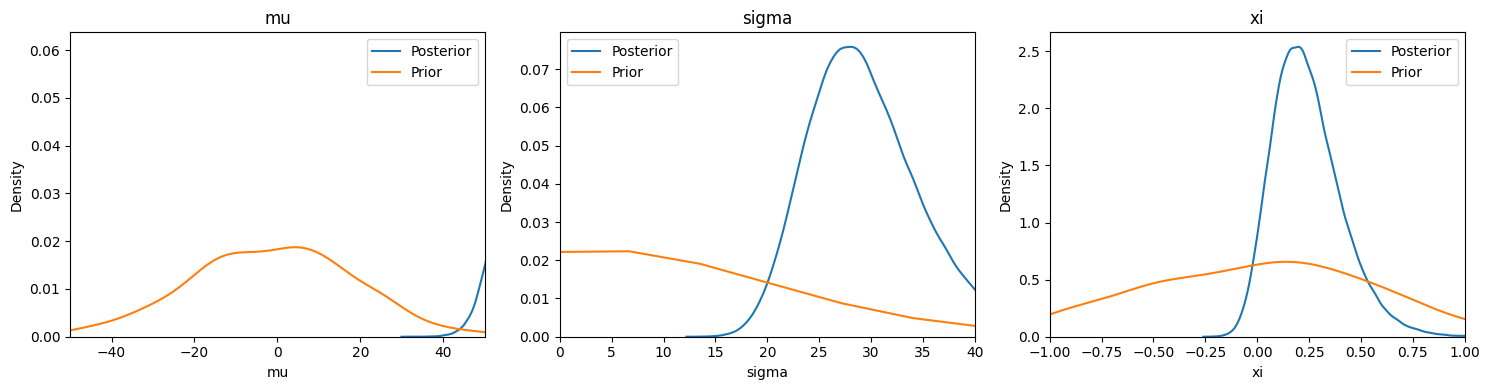

In [113]:
plot_prior_posterior(fit)

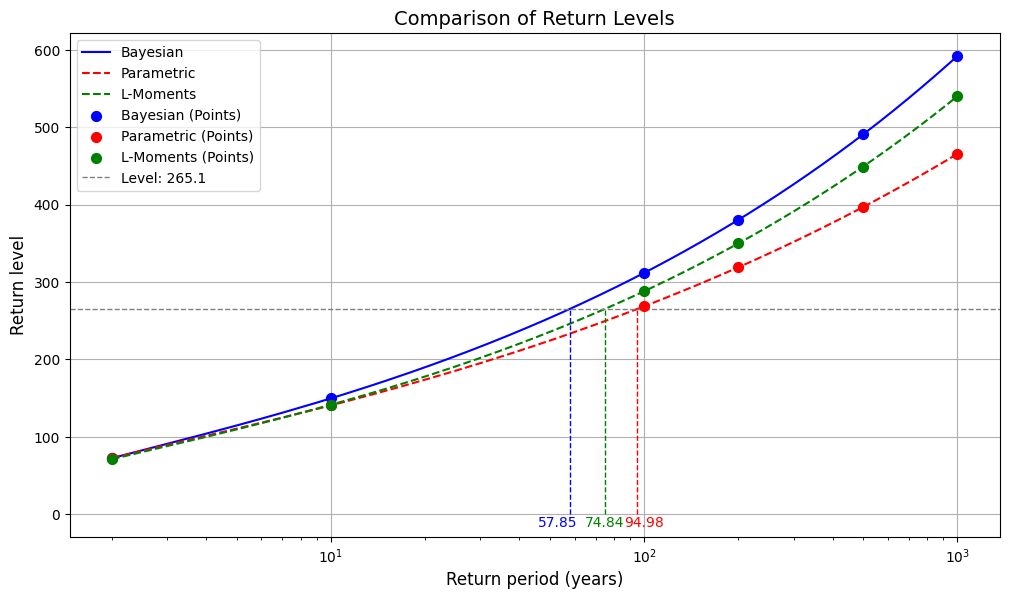

       Bayes    Para  l-moments
T                              
2      72.40   72.62      71.11
10    149.71  140.60     141.45
100   311.80  268.59     288.09
200   380.44  319.05     349.95
500   490.70  396.87     449.12
1000  591.98  465.56     540.01


In [114]:
lmoments = lm.lmom_ratios(data)
ξ_est, μ_est, σ_est = genextreme.fit(data)
gev_params_lmoments = lmd.gev.lmom_fit(data)
ξ_est_lm = gev_params_lmoments['c']
μ_est_lm = gev_params_lmoments['loc'] 
σ_est_lm = gev_params_lmoments['scale']

# Uso:
T_years = np.array([2,10,100,200,500, 1000])
param_fit = {'mu': μ_est, 'sigma': σ_est, 'xi': -ξ_est}
param_fit_lm = {'mu': μ_est_lm, 'sigma': σ_est_lm, 'xi': -ξ_est_lm}
results = compare_return_periods(data, fit, param_fit,param_fit_lm, dx1=-5, dx2=+5, dx3=0, dy1=0, dy2=0, dy3=0,
                                 T_years=T_years,value=z_value, savefile="Analisis_Basic_Including_2.jpg")
print(results)

In [115]:
os.makedirs('Resultados_RP/Puntual/',exist_ok=True)
results.to_csv('Resultados_RP/Puntual/Analisis_Puntual_RP_V103_CON_DANA.csv')

## Análisis de las estaciones seleccionadas


In [179]:
def plot_return_period_comparison(data, fit_bayes, confidence_level=0.95, n_sims=1000, title='Figure title'):
    from scipy import stats
    from scipy.stats import multivariate_normal
    """
    Generates a comparative return period plot using parametric GEV fitting
    and Bayesian fitting.
    
    Parameters:
    data: Maximum precipitation data.
    fit_bayes: Bayesian fit (posterior samples as DataFrame).
    confidence_level: Confidence level for the bands (default: 0.95).
    n_sims: Number of simulations for the parametric confidence bands (default: 1000).
    """

    bayes_posteriors = fit_bayes.to_frame()

    # Sort data from highest to lowest
    sorted_data = np.sort(data)[::-1]
    n = len(sorted_data)
    
    # Compute empirical return period (Weibull plotting position)
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    
    # Parametric GEV fit (MLE)
    theta_mle = stats.genextreme.fit(sorted_data)
    shape_mle, loc_mle, scale_mle = theta_mle
    
    # Bayesian parameters
    shape_bayes = -np.mean(bayes_posteriors['xi'])
    loc_bayes = np.mean(bayes_posteriors['mu'])
    scale_bayes = np.mean(bayes_posteriors['sigma'])
    
    # Define points for fitted lines
    T_fit = np.logspace(np.log10(1.06), np.log10(max(return_period)) + 1.05, 100)
    p_fit = 1 - 1 / T_fit
    
    # Calculate quantiles for both fits
    quantiles_mle = stats.genextreme.ppf(p_fit, shape_mle, loc=loc_mle, scale=scale_mle)
    quantiles_bayes = stats.genextreme.ppf(p_fit, shape_bayes, loc=loc_bayes, scale=scale_bayes)
    
    # Compute confidence bands for parametric fit
    acov = ACOV(genextreme.nnlf, theta_mle, sorted_data)
    theta_gen = np.array(theta_mle)
    theta_sim = multivariate_normal.rvs(theta_gen, acov, size=n_sims)
    
    sim_quantiles_mle = np.zeros((n_sims, len(T_fit)))
    for i in range(n_sims):
        sim_quantiles_mle[i, :] = stats.genextreme.ppf(p_fit, 
                                                      theta_sim[i, 0],
                                                      theta_sim[i, 1],
                                                      theta_sim[i, 2])
    
    lower_band_mle = np.percentile(sim_quantiles_mle, (1 - confidence_level) * 100 / 2, axis=0)
    upper_band_mle = np.percentile(sim_quantiles_mle, (1 + confidence_level) * 100 / 2, axis=0)
    
    # Compute Bayesian confidence bands using posterior samples
    n_post = len(bayes_posteriors['xi'])
    sim_quantiles_bayes = np.zeros((n_post, len(T_fit)))
    
    for i in range(n_post):
        sim_quantiles_bayes[i, :] = stats.genextreme.ppf(p_fit,
                                                        -bayes_posteriors['xi'][i],
                                                        bayes_posteriors['mu'][i],
                                                        bayes_posteriors['sigma'][i])
    
    lower_band_bayes = np.percentile(sim_quantiles_bayes, (1 - confidence_level) * 100 / 2, axis=0)
    upper_band_bayes = np.percentile(sim_quantiles_bayes, (1 + confidence_level) * 100 / 2, axis=0)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot empirical points
    ax.scatter(return_period, sorted_data, c='0.7', label='Observed data', s=25, zorder=6, lw=0.8, edgecolors='0.3', alpha=0.7)
    
    # Plot fitted lines
    ax.plot(T_fit, quantiles_mle, 'r-', label='MLE Fit', linewidth=2)
    ax.plot(T_fit, quantiles_bayes, 'b-', label='Bayesian Fit', linewidth=2)
    
    # Plot confidence bands
    ax.fill_between(T_fit, lower_band_mle, upper_band_mle, color='red', alpha=0.1,
                   label=f'MLE {confidence_level*100:.0f}% confidence band')
    ax.fill_between(T_fit, lower_band_bayes, upper_band_bayes, color='blue', alpha=0.1,
                   label=f'Bayesian {confidence_level*100:.0f}% confidence band')
    
    # Configure axes
    ax.set_xscale('log')
    ax.set_yscale('linear')
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    
    # Labels and title
    ax.set_xlabel('Return period (years)')
    ax.set_ylabel('Return level (mm/day)')
    ax.set_title(title)
    
    # Define axis limits
    ax.set_ylim(0, max(data) * 1.5)
    ax.set_xlim(1, 20)
    
    # Calculate posterior statistics
    bayes_std = {
        'xi': np.std(bayes_posteriors['xi']),
        'mu': np.std(bayes_posteriors['mu']),
        'sigma': np.std(bayes_posteriors['sigma'])
    }
    
    # MLE standard errors
    std_errors_mle = np.sqrt(np.diag(acov))
    
    # Text for MLE parameters
    param_text_mle = (f'GEV Parameters (MLE ± std):\n'
                     f'ξ (shape) = {shape_mle:.3f} ± {std_errors_mle[0]:.3f}\n'
                     f'μ (location) = {loc_mle:.3f} ± {std_errors_mle[1]:.3f}\n'
                     f'σ (scale) = {scale_mle:.3f} ± {std_errors_mle[2]:.3f}')
    
    # Text for Bayesian parameters
    param_text_bayes = (f'GEV Parameters (Bayesian ± std):\n'
                       f'ξ (shape) = {shape_bayes:.3f} ± {bayes_std["xi"]:.3f}\n'
                       f'μ (location) = {loc_bayes:.3f} ± {bayes_std["mu"]:.3f}\n'
                       f'σ (scale) = {scale_bayes:.3f} ± {bayes_std["sigma"]:.3f}')
    
    # Add parameter text boxes
    ax.text(0.2, 0.45, param_text_mle, transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'),
            verticalalignment='bottom', horizontalalignment='right')
    
    ax.text(0.225, 0.61, param_text_bayes, transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue'),
            verticalalignment='bottom', horizontalalignment='right')
    
    ax.legend(loc='upper left')
    plt.tight_layout()
    
    return fig, ax


In [180]:
est_analisis = ['8337X','V103']

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 2.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.25 seconds.
  Adjust your expectations accordingly!
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
warn:Rejecting initial value:
warn:  Log probability

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 9e-06 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.09 seconds.
  Adjust your expectations accordingly!
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
warn:Rejecting initial value:
warn:  Log probability e

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 5.7e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.57 seconds.
  Adjust your expectations accordingly!
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
warn:Rejecting initial value:
warn:  Log probability

Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
  Gradient evaluation took 1.4e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.14 seconds.
  Adjust your expectations accordingly!
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
warn:Rejecting initial value:
warn:  Log probability

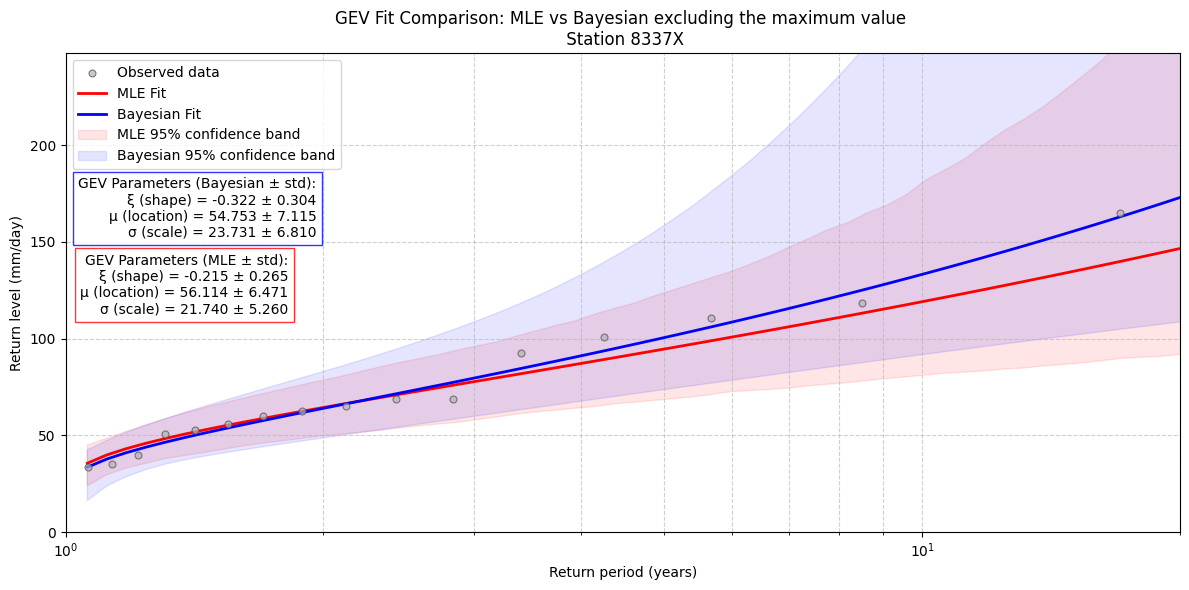

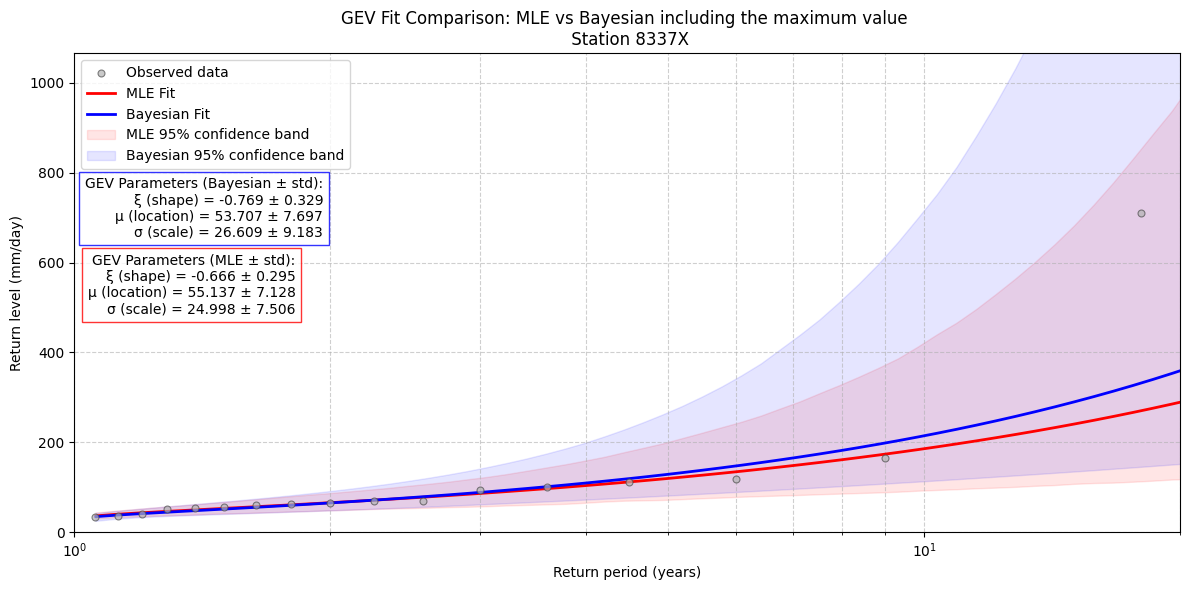

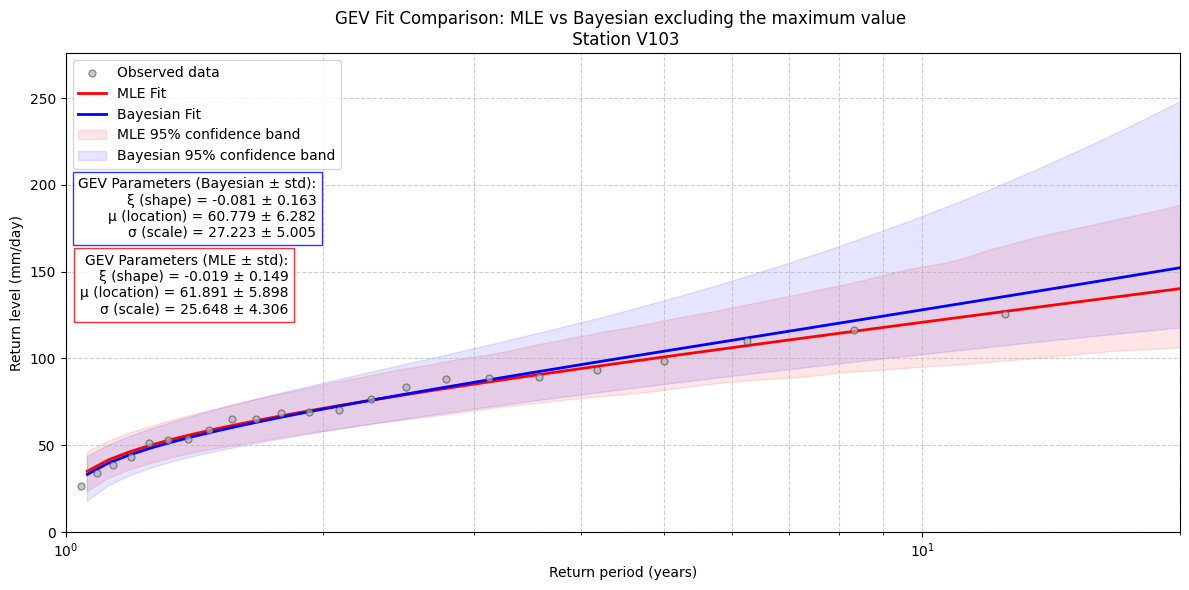

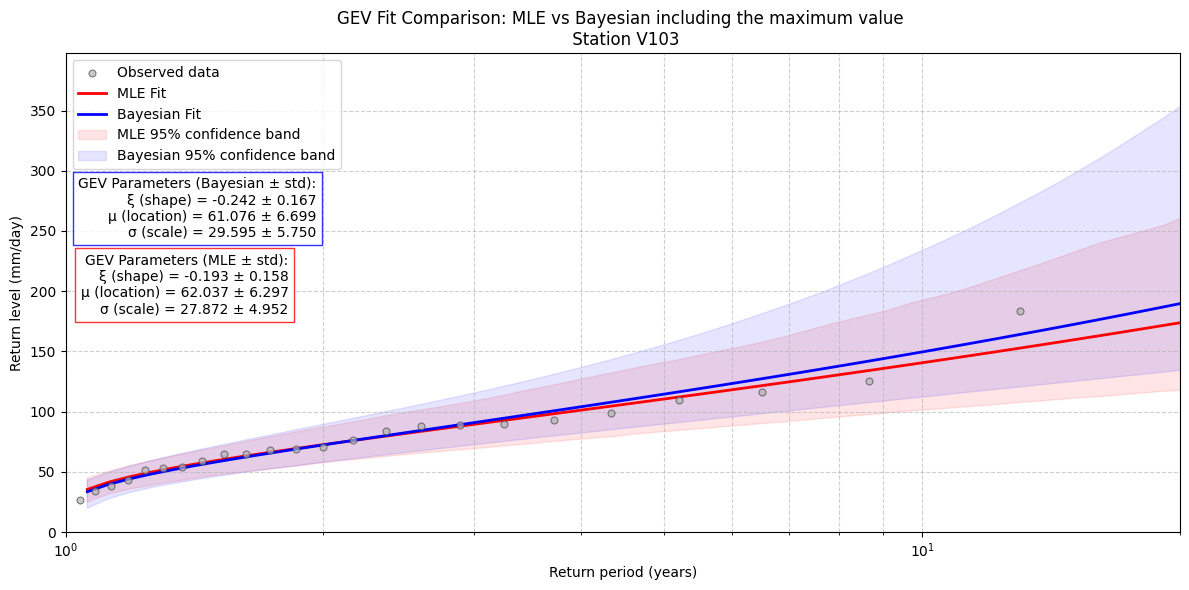

In [181]:
for st in est_analisis:
    data_1 = prec_day[st].resample('D').sum(min_count=1).resample('YE').max(min_count=1).dropna().values.astype(float) # Incluyendo el dato máximo
    data_0 = data_1[:-1]  # Sin incluir el dato máximo

    z_value = data_1.max()

    # Preparar datos para Stan
    data_dict_0 = {
        'N': len(data_0),
        'y': data_0.astype(float)  # o data.to_numpy() si es un DataFrame
    }
    posterior_0 = stan.build(gev_model, data=data_dict_0,random_seed=42)
    # Ajustar modelo
    fit_0 = posterior_0.sample(num_chains=20, num_samples=10000, num_warmup=2000)
    # Mostrar los resultados

    data_dict_1 = {
        'N': len(data_1),
        'y': data_1.astype(float)  # o data.to_numpy() si es un DataFrame
    }

    posterior_1 = stan.build(gev_model, data=data_dict_1,random_seed=42)
    # Ajustar modelo
    fit_1 = posterior_1.sample(num_chains=20, num_samples=10000, num_warmup=2000)
    # Mostrar los resultados

    T_years = np.array([2, 5, 10, 20, 50, 100, 500, 1000])

    ξ_est_0, μ_est_0, σ_est_0 = genextreme.fit(data_0)
    param_fit_0 = {'mu': μ_est_0, 'sigma': σ_est_0, 'xi': -ξ_est_0}
    #results_0 = compare_return_periods(data_0, fit_0, param_fit_0, T_years, value=z_value,title=f"Comparación de Ajustes GEV: MLE vs Bayesiano sin valor máximo \n Estación AEMET-{st}")
    plot_return_period_comparison(data_0, fit_0, confidence_level=0.95, n_sims=1000, title=f"GEV Fit Comparison: MLE vs Bayesian excluding the maximum value \n Station {st}")

    ξ_est_1, μ_est_1, σ_est_1 = genextreme.fit(data_1)
    param_fit_1 = {'mu': μ_est_1, 'sigma': σ_est_1, 'xi': -ξ_est_1}
    #results_1   = compare_return_periods(data_1, fit_1, param_fit_1, T_years, value=z_value,title=f"Comparación de Ajustes GEV: MLE vs Bayesiano con valor máximo \n Estación AEMET-{st}")
    plot_return_period_comparison(data_1, fit_1, confidence_level=0.95, n_sims=1000, title=f"GEV Fit Comparison: MLE vs Bayesian including the maximum value \n Station {st}")

# Análisis RFA 

In [182]:
def compare_return_periods_MANU(data, fit_bayes, fit_param,fit_param_lmoments, mean_station,sigma_station, dx1=0, dx2=0, dx3=0, dy1=0, dy2=0, dy3=0, T_years=np.array([2, 5, 10, 20, 50, 100]), 
                           plot=True, value=None, title="Comparison of Return Levels"):
    """
    Compara períodos de retorno entre análisis paramétrico, bayesiano y empírico.
    Permite calcular el período de retorno para un valor dado y visualizarlo.

    Args:
        data: datos originales.
        fit_bayes: ajuste bayesiano (objeto Stan o DataFrame simulado).
        fit_param: parámetros del ajuste paramétrico (dict con 'mu', 'sigma', 'xi').
        T_years: array con periodos de retorno a calcular.
        plot: si True, genera gráfico comparativo.
        value: valor para el cual calcular el período de retorno y marcarlo en el gráfico.
        title: título del gráfico (opcional).

    Returns:
        DataFrame con niveles de retorno calculados.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import genextreme as gev
    import pandas as pd

    # Extraer parámetros medios del ajuste bayesiano
    bayes_params = fit_bayes.to_frame()
    bayes_mean = {
        'mu': np.mean(bayes_params['mu']),
        'sigma': np.mean(bayes_params['sigma']),
        'xi': np.mean(bayes_params['xi'])
    }

    # Crear un rango denso de períodos de retorno para líneas suaves
    t_years = np.arange(np.min(T_years), np.max(T_years) + 1, 1)
    p_dense = 1 - 1 / t_years

    # Calcular niveles de retorno teóricos para el rango denso
    z_bayes_dense = gev.ppf(p_dense, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma'])
    z_param_dense = gev.ppf(p_dense, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma'])
    z_lmoments_dense = gev.ppf(p_dense, c=-fit_param_lmoments['xi'], loc=fit_param_lmoments['mu'], scale=fit_param_lmoments['sigma'])

    z_param_dense    = mean_station+z_param_dense*sigma_station
    z_bayes_dense    = mean_station+z_bayes_dense*sigma_station
    z_lmoments_dense = mean_station+z_lmoments_dense*sigma_station

    # Calcular niveles de retorno para los períodos especificados (T_years)
    p = 1 - 1 / T_years
    z_bayes = gev.ppf(p, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma'])
    z_param = gev.ppf(p, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma'])
    z_lmoments = gev.ppf(p, c=-fit_param_lmoments['xi'], loc=fit_param_lmoments['mu'], scale=fit_param_lmoments['sigma'])
    
    z_param = mean_station+z_param*sigma_station
    z_bayes = mean_station+z_bayes*sigma_station
    z_lmoments = mean_station+z_lmoments*sigma_station

    # Calcular período de retorno para un valor dado
    if value is not None:
        # Bayesiano
        bayes_T = 1 / (1 - gev.cdf(value, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma']))
        #bayes_T = mean_station+bayes_T*sigma_station

        # Paramétrico
        param_T = 1 / (1 - gev.cdf(value, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma']))
        #param_T = mean_station+param_T*sigma_station

        # L-Moments
        lmoments_T = 1 / (1 - gev.cdf(value, c=-fit_param_lmoments['xi'], loc=fit_param_lmoments['mu'], scale=fit_param_lmoments['sigma']))
        #param_T = mean_station+param_T*sigma_station

    # Crear DataFrame con resultados y establecer T como índice
    results = pd.DataFrame({
        'Bayes': z_bayes,
        'Para': z_param,
        'L-Moments': z_lmoments,
    }, index=T_years).round(2)
    results.index.name = 'T'  # Nombrar el índice como T

    # Gráfico si se solicita
    if plot:
        plt.figure(figsize=(12, 18))

        # Niveles de retorno teóricos (líneas suaves)
        plt.plot(t_years, z_bayes_dense, 'b-', label='Bayesian')
        plt.plot(t_years, z_param_dense, 'r--', label='Parametric')
        plt.plot(t_years, z_lmoments_dense, 'g--', label='L-Moments')

        # Línea empírica ajustada
        # plt.plot(T_years, z_emp, color='g', linestyle='-', label='Empírico (Ajuste)')

        # Puntos calculados para T_years
        plt.scatter(T_years, z_bayes, c='b', label='Bayesian (Points)', s=50, zorder=3)
        plt.scatter(T_years, z_param, c='r', label='Parametric (Points)', s=50, zorder=3)
        plt.scatter(T_years, z_lmoments, c='g', label='L-Moments (Points)', s=50, zorder=3)

        # Puntos empíricos calculados
        # plt.scatter(T_years, z_emp, c='g', label='Empírico (Puntos)', alpha=0.7, s=50, zorder=2)

        # Marcar el valor dado y añadir líneas
        if value is not None:
            value = mean_station+value*sigma_station
            plt.axhline(y=value, color='gray', linestyle='--', linewidth=1, label=f'Level: {value}')
            # Líneas verticales que terminan en el nivel
            plt.plot([bayes_T, bayes_T], [0, value], color='b', linestyle='--', linewidth=1)
            plt.plot([param_T, param_T], [0, value], color='r', linestyle='--', linewidth=1)
            plt.plot([lmoments_T, lmoments_T], [0, value], color='g', linestyle='--', linewidth=1)

            # Etiquetas en el eje X
            plt.text(bayes_T+dx1, -2+dy1, f'{bayes_T:.2f}', color='b', fontsize=10, ha='center', va='top')
            plt.text(param_T+dx2, -2+dy2, f'{param_T:.2f}', color='r', fontsize=10, ha='center', va='top')
            plt.text(lmoments_T+dx3, -2+dy3, f'{lmoments_T:.2f}', color='g', fontsize=10, ha='center', va='top')

        # Personalización del gráfico
        plt.xscale('log')
        plt.xlabel('Return period (years)', fontsize=12)
        plt.ylabel('Return level', fontsize=12)
        plt.title(title, fontsize=14)  # Usar el título proporcionado
        plt.legend()
        plt.grid(True)

        # Añadir tabla al gráfico con T como índice
        # table = plt.table(
        #     cellText=results.reset_index().values,
        #     colLabels=['T'] + list(results.columns),  # Añadir T como columna en la tabla
        #     cellLoc='center',
        #     loc='bottom',
        #     bbox=[0.0, -0.55, 1, 0.4]  # Más espacio inferior para evitar superposición
        # )
        # table.auto_set_font_size(False)
        # table.set_fontsize(10)  # Aumentar el tamaño de la fuente
        # table.scale(1, 2.5)  # Incrementar la altura de las filas

        plt.subplots_adjust(bottom=0.6)  # Espacio inferior ajustado para la tabla
        plt.show()

    return results


In [183]:
def compare_return_periods(data, fit_bayes, fit_param,fit_param_lmoments, mu_estacion, T_years=np.array([2, 5, 10, 20, 50, 100]), 
                           plot=True, value=None, title="Comparación de niveles de retorno"):
    """
    Compara períodos de retorno entre análisis paramétrico, bayesiano y empírico.
    Permite calcular el período de retorno para un valor dado y visualizarlo.

    Args:
        data: datos originales.
        fit_bayes: ajuste bayesiano (objeto Stan o DataFrame simulado).
        fit_param: parámetros del ajuste paramétrico (dict con 'mu', 'sigma', 'xi').
        T_years: array con periodos de retorno a calcular.
        plot: si True, genera gráfico comparativo.
        value: valor para el cual calcular el período de retorno y marcarlo en el gráfico.
        title: título del gráfico (opcional).

    Returns:
        DataFrame con niveles de retorno calculados.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import genextreme as gev
    import pandas as pd

    # Extraer parámetros medios del ajuste bayesiano
    bayes_params = fit_bayes.to_frame()
    bayes_mean = {
        'mu': np.mean(bayes_params['mu']),
        'sigma': np.mean(bayes_params['sigma']),
        'xi': np.mean(bayes_params['xi'])
    }

    # Crear un rango denso de períodos de retorno para líneas suaves
    t_years = np.arange(np.min(T_years), np.max(T_years) + 1, 1)
    p_dense = 1 - 1 / t_years

    # Calcular niveles de retorno teóricos para el rango denso
    z_bayes_dense = gev.ppf(p_dense, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma'])
    z_param_dense = gev.ppf(p_dense, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma'])
    z_lmoments_dense = gev.ppf(p_dense, c=-fit_param_lmoments['xi'], loc=fit_param_lmoments['mu'], scale=fit_param_lmoments['sigma'])

    z_param_dense    = z_param_dense*mu_estacion
    z_bayes_dense    = z_bayes_dense*mu_estacion
    z_lmoments_dense = z_lmoments_dense*mu_estacion

    # Calcular niveles de retorno para los períodos especificados (T_years)
    p = 1 - 1 / T_years
    z_bayes = gev.ppf(p, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma'])
    z_param = gev.ppf(p, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma'])
    z_lmoments = gev.ppf(p, c=-fit_param_lmoments['xi'], loc=fit_param_lmoments['mu'], scale=fit_param_lmoments['sigma'])

    z_param    = z_param*mu_estacion
    z_bayes    = z_bayes*mu_estacion
    z_lmoments = z_lmoments*mu_estacion

    # Calcular período de retorno para un valor dado
    if value is not None:
        # Bayesiano
        bayes_T = 1 / (1 - gev.cdf(value, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma']))
        #bayes_T = mean_station+bayes_T*sigma_station

        # Paramétrico
        param_T = 1 / (1 - gev.cdf(value, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma']))
        #param_T = mean_station+param_T*sigma_station

        # L-Moments
        lmoments_T = 1 / (1 - gev.cdf(value, c=-fit_param_lmoments['xi'], loc=fit_param_lmoments['mu'], scale=fit_param_lmoments['sigma']))
        #param_T = mean_station+param_T*sigma_station

    # Crear DataFrame con resultados y establecer T como índice
    results = pd.DataFrame({
        'Bayes': z_bayes,
        'Para': z_param,
        'L-Moments': z_lmoments,
    }, index=T_years).round(2)
    results.index.name = 'T'  # Nombrar el índice como T

    # Gráfico si se solicita
    if plot:
        plt.figure(figsize=(12, 18))

        # Niveles de retorno teóricos (líneas suaves)
        plt.plot(t_years, z_bayes_dense, 'b-', label='Bayesiano')
        plt.plot(t_years, z_param_dense, 'r--', label='Paramétrico')
        plt.plot(t_years, z_lmoments_dense, 'g--', label='L-Momentos')

        # Línea empírica ajustada
        # plt.plot(T_years, z_emp, color='g', linestyle='-', label='Empírico (Ajuste)')

        # Puntos calculados para T_years
        plt.scatter(T_years, z_bayes, c='b', label='Bayesiano (Puntos)', s=50, zorder=3)
        plt.scatter(T_years, z_param, c='r', label='Paramétrico (Puntos)', s=50, zorder=3)
        plt.scatter(T_years, z_lmoments, c='g', label='L-Momentos (Puntos)', s=50, zorder=3)
        

        # Puntos empíricos calculados
        # plt.scatter(T_years, z_emp, c='g', label='Empírico (Puntos)', alpha=0.7, s=50, zorder=2)

        # Marcar el valor dado y añadir líneas
        if value is not None:
            value =value*mu_estacion
            plt.axhline(y=value, color='gray', linestyle='--', linewidth=1, label=f'Nivel: {value}')
            # Líneas verticales que terminan en el nivel
            plt.plot([bayes_T, bayes_T], [0, value], color='b', linestyle='--', linewidth=1)
            plt.plot([param_T, param_T], [0, value], color='r', linestyle='--', linewidth=1)
            plt.plot([lmoments_T, lmoments_T], [0, value], color='g', linestyle='--', linewidth=1)

            # Etiquetas en el eje X
            plt.text(bayes_T, -2, f'{bayes_T:.2f}', color='b', fontsize=10, ha='center', va='top')
            plt.text(param_T, -2, f'{param_T:.2f}', color='r', fontsize=10, ha='center', va='top')
            plt.text(lmoments_T, -2, f'{lmoments_T:.2f}', color='g', fontsize=10, ha='center', va='top')

        # Personalización del gráfico
        plt.xscale('log')
        plt.xlabel('Período de retorno (años)', fontsize=12)
        plt.ylabel('Nivel de retorno', fontsize=12)
        plt.title(title, fontsize=14)  # Usar el título proporcionado
        plt.legend()
        plt.grid(True)

        # Añadir tabla al gráfico con T como índice
        # table = plt.table(
        #     cellText=results.reset_index().values,
        #     colLabels=['T'] + list(results.columns),  # Añadir T como columna en la tabla
        #     cellLoc='center',
        #     loc='bottom',
        #     bbox=[0.0, -0.55, 1, 0.4]  # Más espacio inferior para evitar superposición
        # )
        # table.auto_set_font_size(False)
        # table.set_fontsize(10)  # Aumentar el tamaño de la fuente
        # table.scale(1, 2.5)  # Incrementar la altura de las filas

        plt.subplots_adjust(bottom=0.6)  # Espacio inferior ajustado para la tabla
        plt.show()

    return results


In [184]:
def filtrar_estaciones(df, min_years, max_gap_percentage):
    """
    Filtra estaciones que tienen al menos min_years años válidos con menos de max_gap_percentage de huecos.
    
    Args:
        df (pd.DataFrame): DataFrame con estaciones como columnas y fechas como índice.
        min_years (int): Número mínimo de años válidos requeridos.
        max_gap_percentage (float): Porcentaje máximo de huecos permitido por año.
    
    Returns:
        list: Lista de estaciones que cumplen con los criterios.
    """
    # Asegurarse de que el índice sea tipo datetime
    df.index = pd.to_datetime(df.index)
    
    # Resamplear para agrupar por año y contar datos válidos (no NaN)
    data_per_year = df.resample('Y').apply(lambda x: x.notna().sum())
    
    # Calcular el total de días por año
    total_days_per_year = df.resample('Y').size().values.reshape(-1, 1)
    
    # Calcular el porcentaje de huecos por estación por año
    percentage_gaps_per_year = 100 * (1 - (data_per_year / total_days_per_year))
    
    # Identificar años válidos (menos del max_gap_percentage de huecos)
    valid_years_per_station = (percentage_gaps_per_year < max_gap_percentage).astype(int)
    
    # Contar los años válidos por estación
    years_with_less_than_max_gap = valid_years_per_station.sum()
    
    # Filtrar estaciones con más de min_years años válidos
    stations_with_enough_valid_years = years_with_less_than_max_gap[years_with_less_than_max_gap >= min_years]
    
    # Devolver la lista de estaciones que cumplen los criterios
    return stations_with_enough_valid_years.index.tolist()


In [185]:
def plot_return_period_comparison(data, fit_bayes, confidence_level=0.95, n_sims=1000, title='Figure title'):
    from scipy import stats
    from scipy.stats import multivariate_normal
    """
    Generates a comparative return period plot using parametric GEV fitting
    and Bayesian fitting.
    
    Parameters:
    data: Maximum precipitation data.
    fit_bayes: Bayesian fit (posterior samples as DataFrame).
    confidence_level: Confidence level for the confidence bands (default: 0.95).
    n_sims: Number of simulations for the parametric confidence bands (default: 1000).
    """

    bayes_posteriors = fit_bayes.to_frame()

    # Sort data from highest to lowest
    sorted_data = np.sort(data)[::-1]
    n = len(sorted_data)
    
    # Compute empirical return period (Weibull plotting position)
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    
    # Parametric GEV fit (MLE)
    theta_mle = stats.genextreme.fit(sorted_data)
    shape_mle, loc_mle, scale_mle = theta_mle
    
    # Bayesian parameters
    shape_bayes = -np.mean(bayes_posteriors['xi'])
    loc_bayes = np.mean(bayes_posteriors['mu'])
    scale_bayes = np.mean(bayes_posteriors['sigma'])
    
    # Define points for fitted lines
    T_fit = np.logspace(np.log10(1.06), np.log10(max(return_period)) + 1.05, 100)
    p_fit = 1 - 1 / T_fit
    
    # Calculate quantiles for both fits
    quantiles_mle = stats.genextreme.ppf(p_fit, shape_mle, loc=loc_mle, scale=scale_mle)
    quantiles_bayes = stats.genextreme.ppf(p_fit, shape_bayes, loc=loc_bayes, scale=scale_bayes)
    
    # Calculate confidence bands for parametric fit
    acov = ACOV(genextreme.nnlf, theta_mle, sorted_data)
    theta_gen = np.array(theta_mle)
    theta_sim = multivariate_normal.rvs(theta_gen, acov, size=n_sims)
    
    sim_quantiles_mle = np.zeros((n_sims, len(T_fit)))
    for i in range(n_sims):
        sim_quantiles_mle[i, :] = stats.genextreme.ppf(p_fit,
                                                      theta_sim[i, 0],
                                                      theta_sim[i, 1],
                                                      theta_sim[i, 2])
    
    lower_band_mle = np.percentile(sim_quantiles_mle, (1 - confidence_level) * 100 / 2, axis=0)
    upper_band_mle = np.percentile(sim_quantiles_mle, (1 + confidence_level) * 100 / 2, axis=0)
    
    # Calculate Bayesian confidence bands using posterior samples
    n_post = len(bayes_posteriors['xi'])
    sim_quantiles_bayes = np.zeros((n_post, len(T_fit)))
    
    for i in range(n_post):
        sim_quantiles_bayes[i, :] = stats.genextreme.ppf(p_fit,
                                                        -bayes_posteriors['xi'][i],
                                                        bayes_posteriors['mu'][i],
                                                        bayes_posteriors['sigma'][i])
    
    lower_band_bayes = np.percentile(sim_quantiles_bayes, (1 - confidence_level) * 100 / 2, axis=0)
    upper_band_bayes = np.percentile(sim_quantiles_bayes, (1 + confidence_level) * 100 / 2, axis=0)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot empirical points
    ax.scatter(return_period, sorted_data, c='0.7', label='Observed data', s=25, zorder=6, lw=0.8, edgecolors='0.3', alpha=0.7)
    
    # Plot fitted lines
    ax.plot(T_fit, quantiles_mle, 'r-', label='MLE Fit', linewidth=2)
    ax.plot(T_fit, quantiles_bayes, 'b-', label='Bayesian Fit', linewidth=2)
    
    # Plot confidence bands
    ax.fill_between(T_fit, lower_band_mle, upper_band_mle, color='red', alpha=0.1,
                   label=f'MLE {confidence_level*100:.0f}% confidence band')
    ax.fill_between(T_fit, lower_band_bayes, upper_band_bayes, color='blue', alpha=0.1,
                   label=f'Bayesian {confidence_level*100:.0f}% confidence band')
    
    # Configure axes
    ax.set_xscale('log')
    ax.set_yscale('linear')
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    
    # Labels and title
    ax.set_xlabel('Return period (years)')
    ax.set_ylabel('Return level (mm/day)')
    ax.set_title(title)

    # Define axis limits
    ax.set_ylim(-2, 7.5)
    ax.set_xlim(1, 100)
    
    # Calculate posterior statistics
    bayes_std = {
        'xi': np.std(bayes_posteriors['xi']),
        'mu': np.std(bayes_posteriors['mu']),
        'sigma': np.std(bayes_posteriors['sigma'])
    }
    
    # MLE standard errors
    std_errors_mle = np.sqrt(np.diag(acov))
    
    # Text for MLE parameters
    param_text_mle = (f'GEV parameters (MLE ± std):\n'
                     f'ξ (shape) = {shape_mle:.3f} ± {std_errors_mle[0]:.3f}\n'
                     f'μ (location) = {loc_mle:.3f} ± {std_errors_mle[1]:.3f}\n'
                     f'σ (scale) = {scale_mle:.3f} ± {std_errors_mle[2]:.3f}')
    
    # Text for Bayesian parameters
    param_text_bayes = (f'GEV parameters (Bayesian ± std):\n'
                       f'ξ (shape) = {shape_bayes:.3f} ± {bayes_std["xi"]:.3f}\n'
                       f'μ (location) = {loc_bayes:.3f} ± {bayes_std["mu"]:.3f}\n'
                       f'σ (scale) = {scale_bayes:.3f} ± {bayes_std["sigma"]:.3f}')
    
    # Add parameter text boxes
    ax.text(0.195, 0.46, param_text_mle, transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'),
            verticalalignment='bottom', horizontalalignment='right')
    
    ax.text(0.225, 0.62, param_text_bayes, transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue'),
            verticalalignment='bottom', horizontalalignment='right')
    
    ax.legend(loc='upper left')
    plt.tight_layout()
    
    return fig, ax


Building...


/usr/local/lib/python3.10/site-packages/pandas/core/apply.py:1081: RuntimeWarning: All-NaN axis encountered
  results[i] = self.func(v, *self.args, **self.kwargs)

Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
  Gradient evaluation took 0.000115 seconds
  1000 tran

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Análisis RFA'}, xlabel='Return period (years)', ylabel='Return level (mm/day)'>)

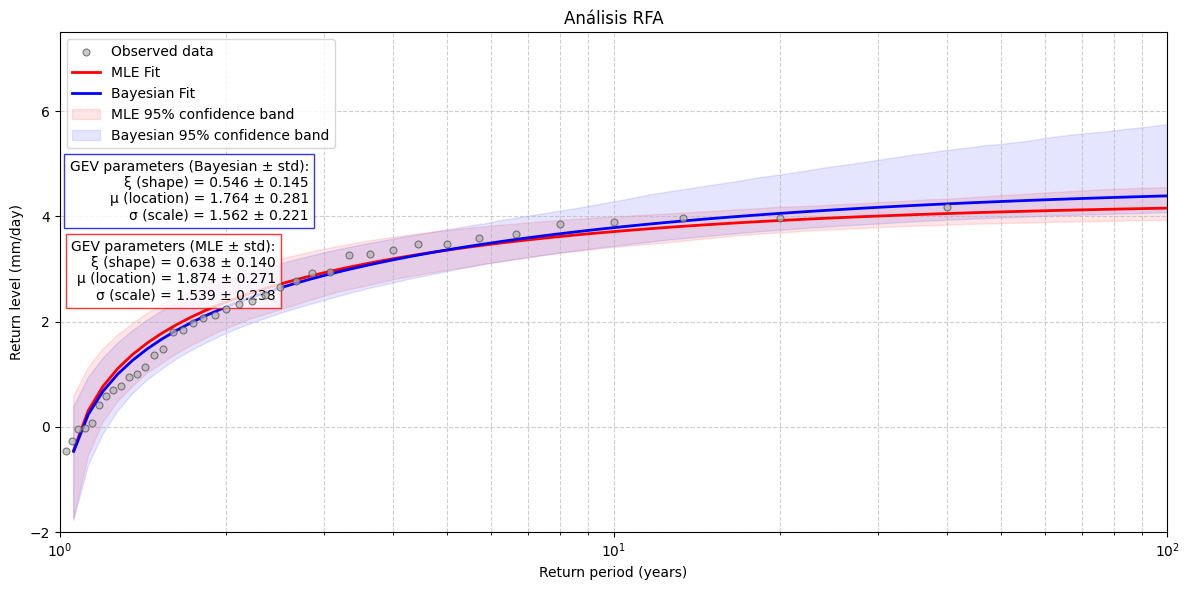

In [186]:
##### Versión Manu ###
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

data_year_max = prec_day.resample('D').sum(min_count=1).resample('YE').max(min_count=1)

scaler = StandardScaler()
data_standardized = pd.DataFrame(
    scaler.fit_transform(data_year_max),
    index=data_year_max.index,
    columns=data_year_max.columns
)

# Calcular el máximo regional ignorando valores NaN
regional_normalized = data_standardized.apply(np.nanmax, axis=1).dropna().values

# Preparar datos para Stan
data_dict = {
    'N': len(regional_normalized),
    'y': regional_normalized.astype(float)  # o data.to_numpy() si es un DataFrame
}
posterior = stan.build(gev_model, data=data_dict,random_seed=42)
# Ajustar modelo
fit = posterior.sample(num_chains=4, num_samples=1000)
# Mostrar los resultados

ξ_est, μ_est, σ_est = genextreme.fit(regional_normalized)
param_fit = {'mu': μ_est, 'sigma': σ_est, 'xi': -ξ_est}

# Paso 7: Ajuste L-Moments
gev_params_lmoments = lmd.gev.lmom_fit(regional_normalized)
ξ_est_lm = gev_params_lmoments['c']
μ_est_lm = gev_params_lmoments['loc'] 
σ_est_lm = gev_params_lmoments['scale']

param_fit_lm = {'mu': μ_est_lm, 'sigma': σ_est_lm, 'xi': -ξ_est_lm}

#results_0 = compare_return_periods(data_0, fit_0, param_fit_0, T_years, value=z_value,title=f"Comparación de Ajustes GEV: MLE vs Bayesiano sin valor máximo \n Estación AEMET-{st}")
plot_return_period_comparison(regional_normalized, fit, confidence_level=0.95, n_sims=1000, title=f"Análisis RFA")


In [187]:
# Suponemos que 'data_year_max' ya está cargado y es un DataFrame
# Calculamos el índice de avenida (media) de todas las estaciones
station = '8337X'
z_value = data_year_max.loc[:,station].max()

# Seleccionar el índice de la estación
estacion_index = data_year_max.columns.get_loc(station)

# Normalizar el valor nuevo
valor_transformado = (z_value - scaler.mean_[estacion_index]) / scaler.scale_[estacion_index]
#valor_transformado = (z_value - scaler.center_[estacion_index]) / scaler.scale_[estacion_index]

print(f"El valor normalizado para la estación {station} es: {valor_transformado}")

El valor normalizado para la estación 8337X es: 3.9052410425813195


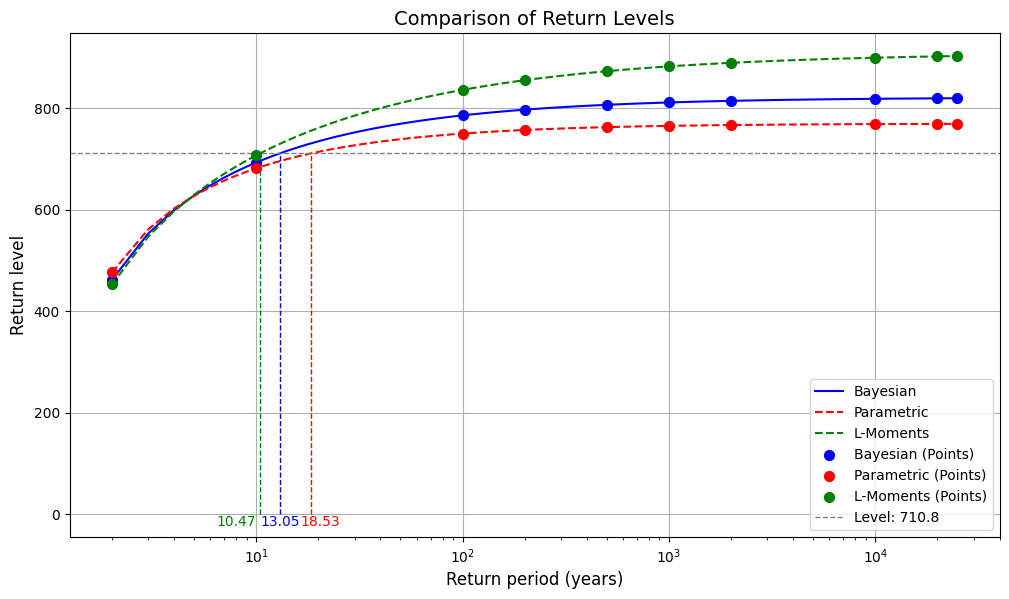

In [188]:
results = compare_return_periods_MANU(regional_normalized, fit, param_fit,param_fit_lm, scaler.mean_[estacion_index],scaler.scale_[estacion_index], 
        dx1=0, dx2=+2, dx3=-2.5, dy1=0, dy2=0, dy3=0,
        T_years=np.array([2,10,100,200,500, 1000, 2000, 10000, 20000,25000]),value=valor_transformado)

In [189]:
os.makedirs('Resultados_RP/Puntual/',exist_ok=True)
results.to_csv('Resultados_RP/Puntual/Analisis_Puntual_RP_Regional_Frecuency_8337X_CON_DANA.csv')

In [190]:
# Suponemos que 'data_year_max' ya está cargado y es un DataFrame
# Calculamos el índice de avenida (media) de todas las estaciones
station = 'V103'
z_value = data_year_max.loc[:,station].max()

# Seleccionar el índice de la estación
estacion_index = data_year_max.columns.get_loc(station)

# Normalizar el valor nuevo
valor_transformado = (z_value - scaler.mean_[estacion_index]) / scaler.scale_[estacion_index]
#valor_transformado = (z_value - scaler.center_[estacion_index]) / scaler.scale_[estacion_index]

print(f"El valor normalizado para la estación {station} es: {valor_transformado}")

El valor normalizado para la estación V103 es: 3.650081171606301


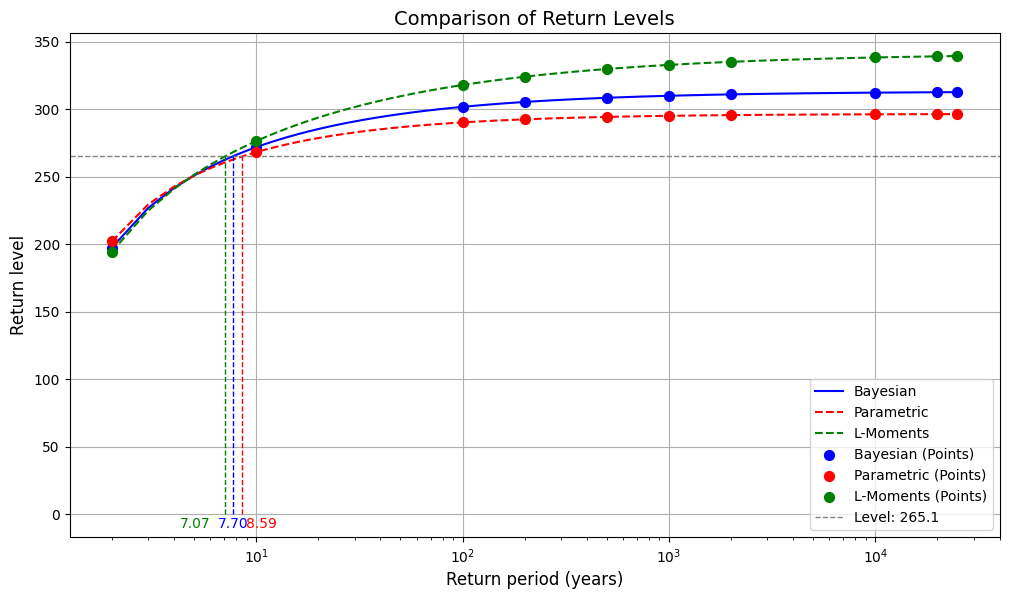

In [191]:
results = compresults = compare_return_periods_MANU(regional_normalized, fit, param_fit,param_fit_lm, scaler.mean_[estacion_index],scaler.scale_[estacion_index], 
                        dx1=0, dx2=+2, dx3=-2, dy1=0, dy2=0, dy3=0,
                        T_years=np.array([2,10,100,200,500, 1000, 2000, 10000, 20000,25000]),value=valor_transformado)

In [192]:
os.makedirs('Resultados_RP/Puntual/',exist_ok=True)
results.to_csv('Resultados_RP/Puntual/Analisis_Puntual_RP_Regional_Frecuency_V103_CON_DANA.csv')

## Sin incluir el año 2024

In [193]:
import pandas as pd

In [194]:
data_day = prec_day.astype(float)
data_year_max_all = data_day.resample('YE').max().astype(float)
data_day = data_day.loc[:'2023']
data_year_max = data_day.resample('YE').max().astype(float)
stations_sel   = filtrar_estaciones(data_day, 10, 20)
data_year_max  = data_year_max.loc[:,stations_sel]

/tmp/ipykernel_3865/2277550091.py:17: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  data_per_year = df.resample('Y').apply(lambda x: x.notna().sum())
/tmp/ipykernel_3865/2277550091.py:20: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  total_days_per_year = df.resample('Y').size().values.reshape(-1, 1)


Building...


/usr/local/lib/python3.10/site-packages/pandas/core/apply.py:1081: RuntimeWarning: All-NaN axis encountered
  results[i] = self.func(v, *self.args, **self.kwargs)

Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 20, column 11: A
    control flow statement depends on parameter(s): mu, sigma, xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 19, column 7: A
    control flow statement depends on parameter(s): xi.
Warning in '/tmp/httpstan_rhw3aqqe/model_qbjreepi.stan', line 13, column 18: Argument
    100 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Sampling:   0%
Sampling: 100%, done.
Messages received during sampling:
warn:Rejecting initial value:
warn:  Log probability evaluates to log(0), i.e. negative infinity.
warn:  Stan can't start sampling from this initial value.
  Gradient evaluation took 1.9e-05 seconds
  1000 trans

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Análisis RFA'}, xlabel='Return period (years)', ylabel='Return level (mm/day)'>)

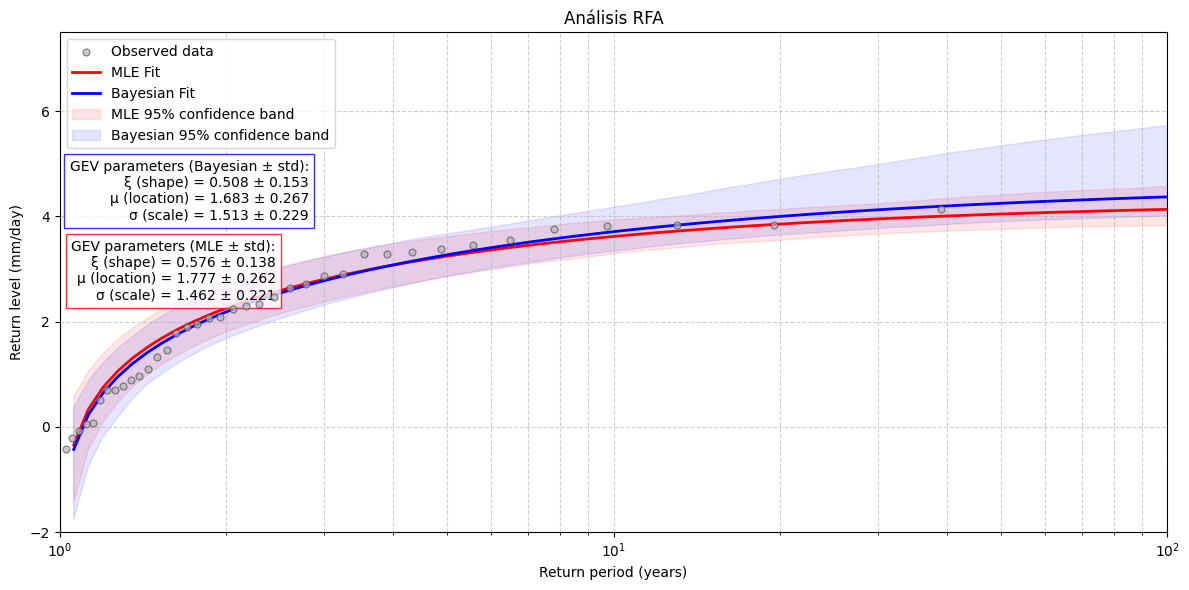

In [195]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

scaler = StandardScaler()
data_standardized = pd.DataFrame(
    scaler.fit_transform(data_year_max),
    index=data_year_max.index,
    columns=data_year_max.columns
)

# Calcular el máximo regional ignorando valores NaN
regional_normalized = data_standardized.apply(np.nanmax, axis=1).dropna().values

# Preparar datos para Stan
data_dict = {
    'N': len(regional_normalized),
    'y': regional_normalized.astype(float)  # o data.to_numpy() si es un DataFrame
}
posterior = stan.build(gev_model, data=data_dict,random_seed=42)
# Ajustar modelo
fit = posterior.sample(num_chains=4, num_samples=1000)
# Mostrar los resultados

ξ_est, μ_est, σ_est = genextreme.fit(regional_normalized)
param_fit = {'mu': μ_est, 'sigma': σ_est, 'xi': -ξ_est}

gev_params_lmoments = lmd.gev.lmom_fit(regional_normalized)
ξ_est_lm = gev_params_lmoments['c']
μ_est_lm = gev_params_lmoments['loc'] 
σ_est_lm = gev_params_lmoments['scale']

param_fit_lm = {'mu': μ_est_lm, 'sigma': σ_est_lm, 'xi': -ξ_est_lm}


#results_0 = compare_return_periods(data_0, fit_0, param_fit_0, T_years, value=z_value,title=f"Comparación de Ajustes GEV: MLE vs Bayesiano sin valor máximo \n Estación AEMET-{st}")
plot_return_period_comparison(regional_normalized, fit, confidence_level=0.95, n_sims=1000, title=f"Análisis RFA")



In [196]:
# Seleccionar el índice de la estación (columna) correspondiente
station = '8337X'
z_value = data_year_max_all.loc[:,station].max()

estacion_index = data_year_max.columns.get_loc(station)

# Normalizar el valor nuevo
valor_transformado = (z_value - scaler.mean_[estacion_index]) / scaler.scale_[estacion_index]
#valor_transformado = (z_value - scaler.center_[estacion_index]) / scaler.scale_[estacion_index]

print(f"El valor normalizado para la estación {station} es: {valor_transformado}")

El valor normalizado para la estación 8337X es: 18.60392629931568


/tmp/ipykernel_3865/1966109052.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  bayes_T = 1 / (1 - gev.cdf(value, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma']))
/tmp/ipykernel_3865/1966109052.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  param_T = 1 / (1 - gev.cdf(value, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma']))
/tmp/ipykernel_3865/1966109052.py:66: RuntimeWarning: divide by zero encountered in scalar divide
  lmoments_T = 1 / (1 - gev.cdf(value, c=-fit_param_lmoments['xi'], loc=fit_param_lmoments['mu'], scale=fit_param_lmoments['sigma']))
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
/usr/local/lib/python3.10/site-packages/matplotlib/transforms.py:354: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]
posx and posy should be finite values
posx and posy should be finite values
pos

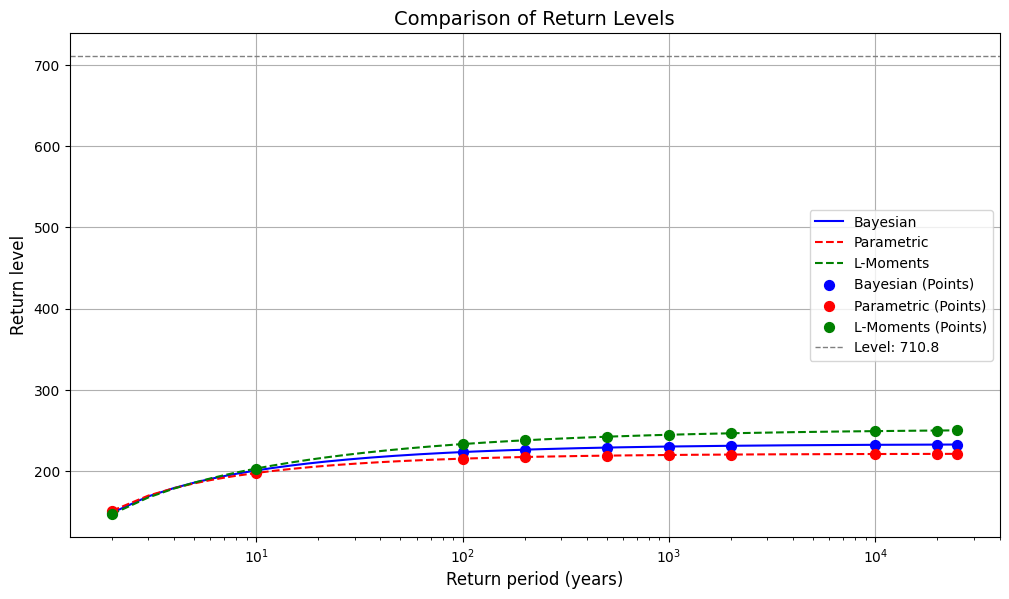

In [197]:
results = compare_return_periods_MANU(regional_normalized, fit, param_fit,param_fit_lm, scaler.mean_[estacion_index],scaler.scale_[estacion_index], 
            dx1=0, dx2=0, dx3=0, dy1=0, dy2=0, dy3=0,
            T_years = np.array([2,10,100,200,500, 1000, 2000, 10000, 20000, 25000]) ,value=valor_transformado)

In [198]:
os.makedirs('Resultados_RP/Puntual/',exist_ok=True)
results.to_csv('Resultados_RP/Puntual/Analisis_Puntual_RP_Regional_Frecuency_8337X_SIN_DANA.csv')

In [199]:
# Seleccionar el índice de la estación (columna) correspondiente
station = 'V103'
z_value = data_year_max_all.loc[:,station].max()

estacion_index = data_year_max.columns.get_loc(station)

# Normalizar el valor nuevo
valor_transformado = (z_value - scaler.mean_[estacion_index]) / scaler.scale_[estacion_index]
#valor_transformado = (z_value - scaler.center_[estacion_index]) / scaler.scale_[estacion_index]

print(f"El valor normalizado para la estación {station} es: {valor_transformado}")

El valor normalizado para la estación V103 es: 5.585342220166019


/tmp/ipykernel_3865/1966109052.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  bayes_T = 1 / (1 - gev.cdf(value, c=-bayes_mean['xi'], loc=bayes_mean['mu'], scale=bayes_mean['sigma']))
/tmp/ipykernel_3865/1966109052.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  param_T = 1 / (1 - gev.cdf(value, c=-fit_param['xi'], loc=fit_param['mu'], scale=fit_param['sigma']))
/tmp/ipykernel_3865/1966109052.py:66: RuntimeWarning: divide by zero encountered in scalar divide
  lmoments_T = 1 / (1 - gev.cdf(value, c=-fit_param_lmoments['xi'], loc=fit_param_lmoments['mu'], scale=fit_param_lmoments['sigma']))
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


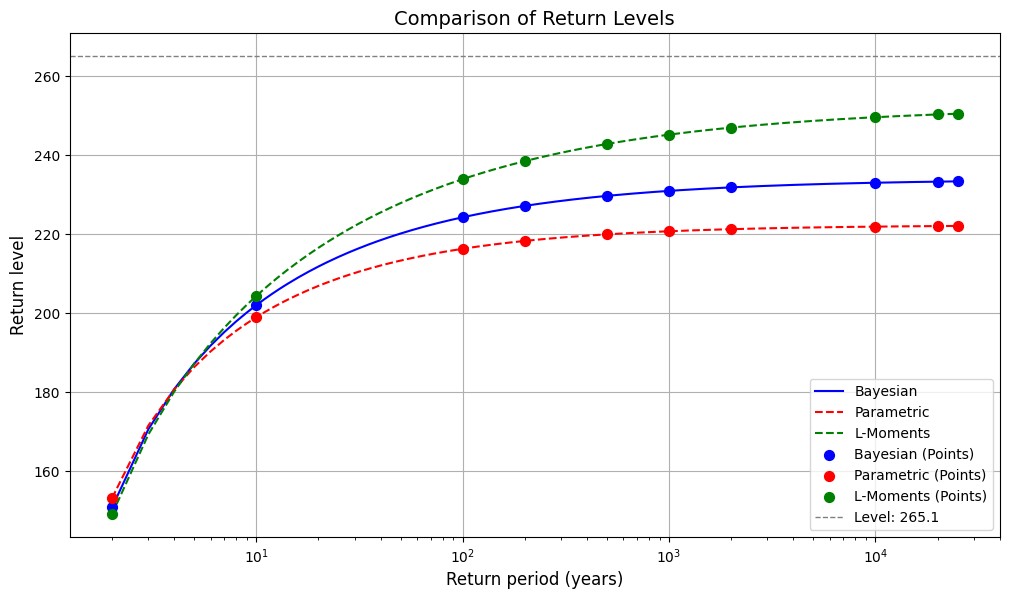

In [200]:
results = compare_return_periods_MANU(regional_normalized, fit, param_fit,param_fit_lm, scaler.mean_[estacion_index],scaler.scale_[estacion_index], 
            dx1=0, dx2=0, dx3=0, dy1=0, dy2=0, dy3=0,
            T_years = np.array([2,10,100,200,500, 1000, 2000, 10000, 20000, 25000]) ,value=valor_transformado)

In [201]:
os.makedirs('Resultados_RP/Puntual/',exist_ok=True)
results.to_csv('Resultados_RP/Puntual/Analisis_Puntual_RP_Regional_Frecuency_V103_SIN_DANA.csv')